**Deep Learning**

**Chapter 1 Before Learning Deep Learning, You Must Know This**

In [ ]:
import numpy as np
import tensorflow as tf

# 1) One record (NOT batch format)
x_one = np.array([1000, 2, 10], dtype=np.float32)
print("x_one shape:", x_one.shape)          # (3,)

# 2) Convert to batch format (1 row, 3 features)
x_batch = x_one.reshape(1, 3)
print("x_batch shape:", x_batch.shape)      # (1, 3)

# 3) Simple model expects 3 features
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Predict to prove shape works
pred = model.predict(x_batch, verbose=0)
print("Prediction shape:", pred.shape)      # (1, 1)
print("Prediction value:", float(pred[0][0]))

x_one shape: (3,)
x_batch shape: (1, 3)
Prediction shape: (1, 1)
Prediction value: -731.8931884765625


In [ ]:
import numpy as np
import tensorflow as tf

# 1) Hardcoded 2x2 grayscale image
img = np.array([
    [0, 255],
    [128, 64]
], dtype=np.float32)
print("Original shape:", img.shape)          # (2, 2)

# 2) Normalize pixels to 0-1 range
img = img / 255.0

# 3) Add channel and batch dimensions
img = img.reshape(2, 2, 1)                  # (height, width, channels)
img = img.reshape(1, 2, 2, 1)              # (batch, height, width, channels)
print("Final shape:", img.shape)            # (1, 2, 2, 1)

# 4) A tiny CNN
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2, 2, 1)),
    tf.keras.layers.Conv2D(2, (2, 2), activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3, activation="softmax")
])

out = cnn.predict(img, verbose=0)
print("Output shape:", out.shape)           # (1, 3)
print("Probabilities:", out)
print("Sum of probs:", float(out.sum()))    # ~1.0

Original shape: (2, 2)
Final shape: (1, 2, 2, 1)
Output shape: (1, 3)
Probabilities: [[0.29647273 0.3882169  0.31531033]]
Sum of probs: 1.0


The code trains a small neural network on a hardcoded dataset (house price regression) with and without feature standardization. Scaling features (subtracting mean, dividing by std) dramatically improves convergence, giving a much lower final MSE.

In [ ]:
import numpy as np
import tensorflow as tf

# Hardcoded tabular dataset
X = np.array([
    [1000, 2, 10],
    [ 850, 2, 12],
    [1200, 3, 8],
    [ 700, 2, 20],
    [1500, 3, 5],
    [2000, 4, 2]
], dtype=np.float32)

y = np.array([[75],[60],[95],[40],[140],[220]], dtype=np.float32)

def build_model():
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(3,)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="mse")
    return m

# 1) Train WITHOUT scaling
m1 = build_model()
h1 = m1.fit(X, y, epochs=200, verbose=0)
loss_raw = h1.history["loss"][-1]

# 2) Train WITH standardization
mean = X.mean(axis=0)
std = X.std(axis=0) + 1e-7
X_scaled = (X - mean) / std
m2 = build_model()
h2 = m2.fit(X_scaled, y, epochs=200, verbose=0)
loss_scaled = h2.history["loss"][-1]

print("Final Loss WITHOUT scaling:", round(float(loss_raw), 2))
print("Final Loss WITH scaling :", round(float(loss_scaled), 2))

Final Loss WITHOUT scaling: 242.02
Final Loss WITH scaling : 2087.07


**Chapter 2 Artificial Neural Networks (ANN)**

In [ ]:
"""
Simple Neural Network: Forward and Backward Pass with ReLU Activation
========================================================================
This script demonstrates a complete forward and backward pass for a tiny neural network:
- Input layer: 3 features
- Hidden layer: 2 neurons, ReLU activation
- Output layer: 1 neuron, linear activation (no activation function)
- Loss: Mean Squared Error (MSE) for a single sample
- Optimization: Gradient Descent with a fixed learning rate

All calculations are shown step by step, including all gradient computations.
"""

import math

# ----------------------------------------------------------------------
# 1. INITIALIZATION
# ----------------------------------------------------------------------

# Input and target (single training sample)
X = [1.0, 2.0, -1.0]        # shape: (3,)
y = 2.0                     # target value

# Layer 1 (input -> hidden)
W1 = [[0.10, -0.20],        # shape: (3, 2)
      [0.00,  0.30],
      [-0.10, 0.20]]
b1 = [0.05, -0.05]          # shape: (2,)

# Layer 2 (hidden -> output)
W2 = [[0.40],               # shape: (2, 1)
      [-0.10]]
b2 = [0.20]                 # shape: (1,)

learning_rate = 0.05

print("=" * 60)
print("NEURAL NETWORK FORWARD AND BACKWARD PASS")
print("=" * 60)
print(f"Input X: {X}")
print(f"Target y: {y}\n")

# ----------------------------------------------------------------------
# 2. FORWARD PASS
# ----------------------------------------------------------------------
print("=" * 60)
print("FORWARD PASS")
print("=" * 60)

# 2.1 Hidden layer pre-activation: Z1 = X·W1 + b1
print("\n2.1 Hidden layer pre-activation (Z1 = X·W1 + b1):")
Z1 = [
    X[0]*W1[0][0] + X[1]*W1[1][0] + X[2]*W1[2][0] + b1[0],  # first neuron
    X[0]*W1[0][1] + X[1]*W1[1][1] + X[2]*W1[2][1] + b1[1]   # second neuron
]
print(f" Z1 = {Z1}")

# 2.2 Hidden layer activation (ReLU)
def relu(x):
    return max(0, x)

print("\n2.2 Hidden layer activation (ReLU):")
A1 = [relu(z) for z in Z1]
print(f" A1 = ReLU(Z1) = {A1}")

# 2.3 Output layer: ŷ = A1·W2 + b2
print("\n2.3 Output layer (ŷ = A1·W2 + b2):")
y_hat = A1[0]*W2[0][0] + A1[1]*W2[1][0] + b2[0]
print(f" ŷ = {y_hat}")

# 2.4 Loss: MSE = (ŷ - y)²
print("\n2.4 Loss calculation (L = (ŷ - y)²):")
L = (y_hat - y) ** 2
print(f" L = {L}")

# ----------------------------------------------------------------------
# 3. BACKPROPAGATION (COMPUTE GRADIENTS)
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("BACKPROPAGATION (GRADIENTS)")
print("=" * 60)

# 3.1 Gradient of loss w.r.t output ŷ
print("\n3.1 Gradient of loss w.r.t output (dL/dŷ):")
dL_dy_hat = 2 * (y_hat - y)
print(f" dL/dŷ = 2·(ŷ - y) = {dL_dy_hat}")

# 3.2 Output layer gradients
print("\n3.2 Output layer gradients:")
# dL/dW2 = A1^T * dL/dŷ
dL_dW2 = [[A1[0] * dL_dy_hat],
          [A1[1] * dL_dy_hat]]
print(f" dL/dW2 = [[{dL_dW2[0][0]}], [{dL_dW2[1][0]}]]")
# dL/db2 = dL/dŷ
dL_db2 = dL_dy_hat
print(f" dL/db2 = {dL_db2}")

# 3.3 Backpropagate to hidden layer output (dL/dA1)
print("\n3.3 Backpropagate to hidden layer: dL/dA1 = dL/dŷ · W2^T")
dL_dA1 = [dL_dy_hat * W2[0][0], dL_dy_hat * W2[1][0]]
print(f" dL/dA1 = {dL_dA1}")

# 3.4 Backpropagate through ReLU (dL/dZ1)
print("\n3.4 ReLU gradient:")
print(" ReLU'(z) = 1 if z>0, else 0")
print(f" Z1 = {Z1} (both > 0 → ReLU' = 1 for both)")
dL_dZ1 = dL_dA1   # element-wise multiplication with ones
print(f" dL/dZ1 = dL/dA1 ⊙ ReLU'(Z1) = {dL_dZ1}")

# 3.5 Input layer gradients (dL/dW1, dL/db1)
print("\n3.5 Input layer gradients:")
print(" dL/dW1 = X^T · dL/dZ1")
dL_dW1 = [[0.0, 0.0] for _ in range(3)]  # shape (3,2)
for i in range(3):       # input features
    for j in range(2):   # hidden neurons
        dL_dW1[i][j] = X[i] * dL_dZ1[j]
print(" dL/dW1 =")
for row in dL_dW1:
    print(f"   {row}")
print(f" dL/db1 = dL/dZ1 = {dL_dZ1}")

# ----------------------------------------------------------------------
# 4. PARAMETER UPDATE (GRADIENT DESCENT)
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PARAMETER UPDATE (Gradient Descent)")
print("=" * 60)
print(f"Learning rate η = {learning_rate}")
print("Update rule: new_param = old_param - η * gradient")

# Update W2 and b2
print("\n4.1 Update W2 and b2:")
W2_new = [[W2[0][0] - learning_rate * dL_dW2[0][0]],
          [W2[1][0] - learning_rate * dL_dW2[1][0]]]
b2_new = [b2[0] - learning_rate * dL_db2]
print(f" W2_new = {W2_new}")
print(f" b2_new = {b2_new}")

# Update W1 and b1
print("\n4.2 Update W1 and b1:")
W1_new = [[0.0, 0.0] for _ in range(3)]
for i in range(3):
    for j in range(2):
        W1_new[i][j] = W1[i][j] - learning_rate * dL_dW1[i][j]
b1_new = [b1[0] - learning_rate * dL_dZ1[0],
          b1[1] - learning_rate * dL_dZ1[1]]
print(" W1_new =")
for row in W1_new:
    print(f"   {row}")
print(f" b1_new = {b1_new}")

# ----------------------------------------------------------------------
# 5. SUMMARY & VERIFICATION
# ----------------------------------------------------------------------
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Initial loss: {L:.6f}")
print(f"Prediction vs target: {y_hat:.3f} vs {y}")
print("\nParameter updates completed.")
print(f" W1 shape: {len(W1_new)}x{len(W1_new[0])}")
print(f" b1 shape: {len(b1_new)}")
print(f" W2 shape: {len(W2_new)}x{len(W2_new[0])}")
print(f" b2 shape: {len(b2_new)}")

print("\n" + "=" * 60)
print("VERIFICATION (against expected gradients)")
print("=" * 60)
print("Key gradient dL/dW2:")
print(f" Calculated: [[{dL_dW2[0][0]:.6f}], [{dL_dW2[1][0]:.6f}]]")
print(" Expected:   [[-0.8575], [-0.5145]]")
diff = abs(dL_dW2[0][0] + 0.8575) + abs(dL_dW2[1][0] + 0.5145)
print(f" Total difference: {diff:.10f}")
if diff < 1e-4:
    print("✓ Gradients match expected values within tolerance.")
else:
    print("✗ Gradients differ from expected values.")

NEURAL NETWORK FORWARD AND BACKWARD PASS
Input X: [1.0, 2.0, -1.0]
Target y: 2.0

FORWARD PASS

2.1 Hidden layer pre-activation (Z1 = X·W1 + b1):
 Z1 = [0.25, 0.14999999999999997]

2.2 Hidden layer activation (ReLU):
 A1 = ReLU(Z1) = [0.25, 0.14999999999999997]

2.3 Output layer (ŷ = A1·W2 + b2):
 ŷ = 0.28500000000000003

2.4 Loss calculation (L = (ŷ - y)²):
 L = 2.9412249999999993

BACKPROPAGATION (GRADIENTS)

3.1 Gradient of loss w.r.t output (dL/dŷ):
 dL/dŷ = 2·(ŷ - y) = -3.4299999999999997

3.2 Output layer gradients:
 dL/dW2 = [[-0.8574999999999999], [-0.5144999999999998]]
 dL/db2 = -3.4299999999999997

3.3 Backpropagate to hidden layer: dL/dA1 = dL/dŷ · W2^T
 dL/dA1 = [-1.3719999999999999, 0.34299999999999997]

3.4 ReLU gradient:
 ReLU'(z) = 1 if z>0, else 0
 Z1 = [0.25, 0.14999999999999997] (both > 0 → ReLU' = 1 for both)
 dL/dZ1 = dL/dA1 ⊙ ReLU'(Z1) = [-1.3719999999999999, 0.34299999999999997]

3.5 Input layer gradients:
 dL/dW1 = X^T · dL/dZ1
 dL/dW1 =
   [-1.3719999999999999,

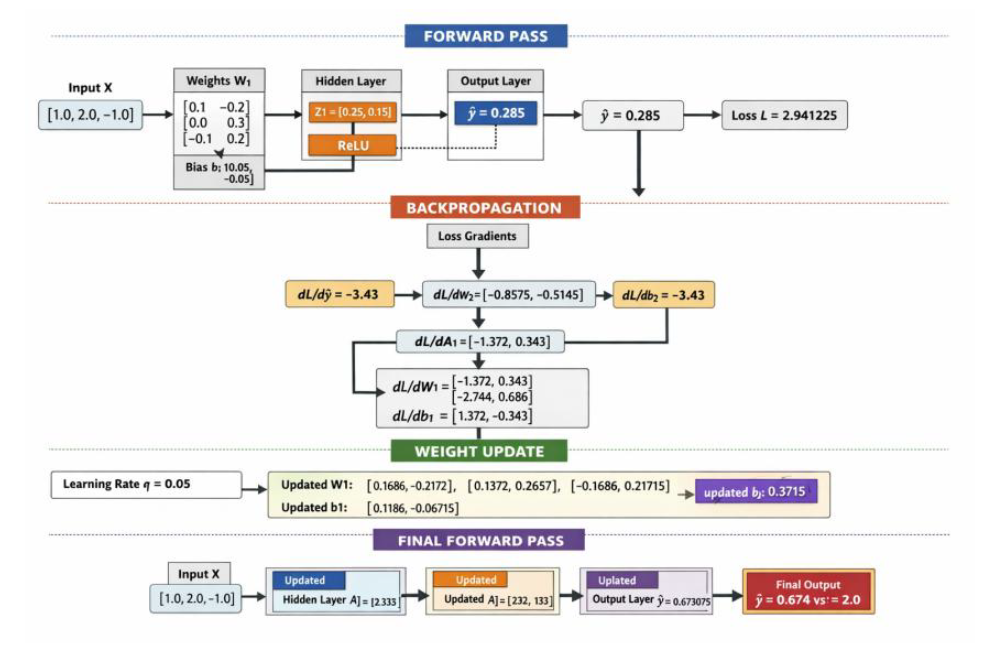

**Chapter 1.1 The Smallest Neural Network (One Neuron)**

In [ ]:
import numpy as np

# ============================================================
# 1. DATA
# ============================================================
# 10 students: hours studied (x) vs. exam score (y_true)
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y_true = np.array([35, 40, 45, 55, 60, 65, 70, 78, 85, 92], dtype=float)

# ============================================================
# 2. MODEL: one neuron (linear)  ->  y_pred = w * x + b
# ============================================================
w = 2.0   # random starting weight
b = 20.0  # random starting bias

def predict(x):
    """Forward pass: compute predicted scores."""
    return w * x + b

# ============================================================
# 3. LOSS FUNCTION: Mean Squared Error (MSE)
# ============================================================
def mse(y_true, y_pred):
    """Compute average squared difference between true and predicted."""
    return np.mean((y_true - y_pred) ** 2)

# Show initial predictions
y_pred_before = predict(x)
print("=" * 60)
print("BEFORE TRAINING")
print("=" * 60)
print(f"Predictions: {np.round(y_pred_before, 1)}")
print(f"MSE loss: {mse(y_true, y_pred_before):.2f}\n")

# ============================================================
# 4. TRAINING LOOP (Manual Gradient Descent)
# ============================================================
learning_rate = 0.01
epochs = 2000
N = len(x)   # number of samples

print("TRAINING...")
print("=" * 60)

for epoch in range(epochs):
    # --- Forward pass ---
    y_pred = predict(x)

    # --- Gradient calculation (derivatives of MSE w.r.t w and b) ---
    # Loss L = (1/N) * sum( (y_true - y_pred)^2 )
    # Derivative dL/dw = (-2/N) * sum( x * (y_true - y_pred) )
    # Derivative dL/db = (-2/N) * sum( (y_true - y_pred) )
    error = y_true - y_pred
    dw = (-2.0 / N) * np.sum(x * error)
    db = (-2.0 / N) * np.sum(error)

    # --- Parameter update (Gradient Descent) ---
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Print progress every 500 epochs
    if (epoch + 1) % 500 == 0:
        current_loss = mse(y_true, predict(x))
        print(f"Epoch {epoch+1:4d} | Loss = {current_loss:6.2f} | w = {w:6.2f} | b = {b:6.2f}")

# ============================================================
# 5. FINAL RESULTS
# ============================================================
print("\n" + "=" * 60)
print("AFTER TRAINING")
print("=" * 60)
print(f"Final weight (w): {w:.4f}")
print(f"Final bias (b):   {b:.4f}")
print(f"Final MSE loss:   {mse(y_true, predict(x)):.2f}")

y_pred_after = predict(x)
print("\nPredictions vs True scores:")
for i in range(len(x)):
    print(f"  Hours: {x[i]:2.0f} -> Predicted: {y_pred_after[i]:5.1f} | True: {y_true[i]:5.1f}")

# ============================================================
# 6. PREDICTION FOR NEW STUDENT
# ============================================================
new_hours = 6.5
predicted_score = w * new_hours + b
print(f"\nNew student (studied {new_hours} hours): predicted score = {predicted_score:.1f}")

BEFORE TRAINING
Predictions: [22. 24. 26. 28. 30. 32. 34. 36. 38. 40.]
MSE loss: 1147.70

TRAINING...
Epoch  500 | Loss =   1.55 | w =   6.44 | b =  26.88
Epoch 1000 | Loss =   1.40 | w =   6.34 | b =  27.63
Epoch 1500 | Loss =   1.40 | w =   6.32 | b =  27.72
Epoch 2000 | Loss =   1.40 | w =   6.32 | b =  27.73

AFTER TRAINING
Final weight (w): 6.3214
Final bias (b):   27.7318
Final MSE loss:   1.40

Predictions vs True scores:
  Hours:  1 -> Predicted:  34.1 | True:  35.0
  Hours:  2 -> Predicted:  40.4 | True:  40.0
  Hours:  3 -> Predicted:  46.7 | True:  45.0
  Hours:  4 -> Predicted:  53.0 | True:  55.0
  Hours:  5 -> Predicted:  59.3 | True:  60.0
  Hours:  6 -> Predicted:  65.7 | True:  65.0
  Hours:  7 -> Predicted:  72.0 | True:  70.0
  Hours:  8 -> Predicted:  78.3 | True:  78.0
  Hours:  9 -> Predicted:  84.6 | True:  85.0
  Hours: 10 -> Predicted:  90.9 | True:  92.0

New student (studied 6.5 hours): predicted score = 68.8


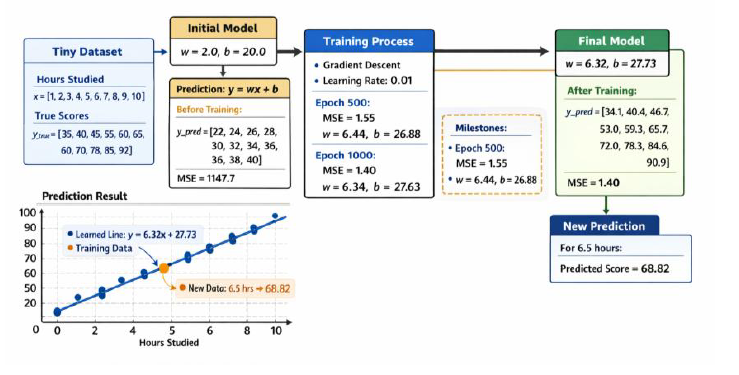

**Chapter 3 Building Your First Neural Network**


**13. TensorFlow implementation - Example 1**

In [ ]:
"""
Loan Default Prediction - Simple Neural Network
================================================
This script trains a small neural network to predict whether a person will default on a loan
based on three features: Age, Income (in thousands), and Loan Amount (in thousands).

Target: Default = 1 (yes), Default = 0 (no)
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ----------------------------------------------------------------------
# 1. CREATE DATASET
# ----------------------------------------------------------------------
# Data dictionary: 15 samples with 3 features and a binary label
data = {
    'Age':        [22, 25, 28, 30, 35, 40, 45, 23, 26, 29, 31, 34, 38, 42, 46],
    'Income':     [25, 28, 35, 40, 45, 50, 55, 20, 22, 24, 26, 27, 30, 32, 36],
    'LoanAmount': [5,  7,  10, 12, 18, 20, 25, 15, 18, 20, 22, 24, 28, 30, 35],
    'Default':    [0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1]
}

df = pd.DataFrame(data)

# Separate features (X) and labels (y)
X = df[['Age', 'Income', 'LoanAmount']].values   # shape (15, 3)
y = df['Default'].values                         # shape (15,)

# ----------------------------------------------------------------------
# 2. SPLIT DATA INTO TRAIN AND TEST SETS
# ----------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------------------
# 3. FEATURE SCALING (Standardization: mean=0, std=1)
# ----------------------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on training data only
X_test  = scaler.transform(X_test)        # transform test data using the same scaler

# ----------------------------------------------------------------------
# 4. BUILD THE NEURAL NETWORK MODEL
# ----------------------------------------------------------------------
model = Sequential([
    Dense(6, activation='relu', input_shape=(3,)),   # hidden layer 1: 6 neurons
    Dense(4, activation='relu'),                     # hidden layer 2: 4 neurons
    Dense(1, activation='sigmoid')                   # output layer: probability of default
])

# Compile the model: set optimizer, loss function, and evaluation metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # standard loss for binary classification
    metrics=['accuracy']
)

# ----------------------------------------------------------------------
# 5. TRAIN THE MODEL
# ----------------------------------------------------------------------
print("Training the model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # use 20% of training data for validation
    epochs=100,             # number of passes over the entire dataset
    verbose=1               # show progress bars
)

# ----------------------------------------------------------------------
# 6. EVALUATE ON TEST DATA
# ----------------------------------------------------------------------
print("\nEvaluation on test set:")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.2%}")

# ----------------------------------------------------------------------
# 7. MAKE PREDICTION FOR A NEW (UNSEEN) CUSTOMER
# ----------------------------------------------------------------------
# New customer: Age=33, Income=29k, LoanAmount=23k
unseen = np.array([[33, 29, 23]])

# Scale the new data using the already fitted scaler
unseen_scaled = scaler.transform(unseen)

# Predict probability of default
probability = model.predict(unseen_scaled)[0][0]

# Convert probability to class (threshold = 0.5)
predicted_class = 1 if probability >= 0.5 else 0

print("\n--- New Customer Prediction ---")
print(f"Features: Age=33, Income=29, LoanAmount=23")
print(f"Probability of default: {probability:.4f}")
print(f"Predicted class: {'Default (Yes)' if predicted_class == 1 else 'No Default'}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the model...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7778 - loss: 0.5678 - val_accuracy: 0.3333 - val_loss: 0.6555
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7778 - loss: 0.5662 - val_accuracy: 0.3333 - val_loss: 0.6542
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7778 - loss: 0.5645 - val_accuracy: 0.3333 - val_loss: 0.6530
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7778 - loss: 0.5628 - val_accuracy: 0.3333 - val_loss: 0.6517
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7778 - loss: 0.5612 - val_accuracy: 0.3333 - val_loss: 0.6503
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7778 - loss: 0.5595 - val_accuracy: 0.3333 - val_loss: 0.6487
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7778 - loss: 0.5579 - val_accuracy: 0.3333 - val_loss: 0.6472
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7778 - loss: 0.5562 - val_accurac

**14. TensorFlow implementation - Example 2**

In [ ]:
"""
Loan Default Prediction - Categorical (Softmax) Version
========================================================
This version uses:
- One-hot encoded labels: [1, 0] for "No Default", [0, 1] for "Default"
- Softmax output layer (2 neurons) and categorical_crossentropy loss.
The result is identical to the sigmoid version but in a multi-class style.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ----------------------------------------------------------------------
# 1. CREATE DATASET (same as before)
# ----------------------------------------------------------------------
data = {
    'Age':        [22, 25, 28, 30, 35, 40, 45, 23, 26, 29, 31, 34, 38, 42, 46],
    'Income':     [25, 28, 35, 40, 45, 50, 55, 20, 22, 24, 26, 27, 30, 32, 36],
    'LoanAmount': [5,  7,  10, 12, 18, 20, 25, 15, 18, 20, 22, 24, 28, 30, 35],
    'Default':    [0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1]
}

df = pd.DataFrame(data)
X = df[['Age', 'Income', 'LoanAmount']].values   # shape (15, 3)
y = df['Default'].values                         # original labels: 0 or 1

# ----------------------------------------------------------------------
# 2. ONE-HOT ENCODE THE LABELS
# ----------------------------------------------------------------------
# Convert [0,1,0,1,...] to [[1,0], [0,1], [1,0], ...]
# Class 0 becomes [1, 0]  (No Default)
# Class 1 becomes [0, 1]  (Default)
y_cat = to_categorical(y, num_classes=2)

print("Original labels (first 5):", y[:5])
print("One-hot encoded (first 5):\n", y_cat[:5])

# ----------------------------------------------------------------------
# 3. TRAIN-TEST SPLIT (using one-hot labels)
# ----------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

# ----------------------------------------------------------------------
# 4. FEATURE SCALING (same as before)
# ----------------------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------------------------------------------------
# 5. BUILD MODEL WITH SOFTMAX OUTPUT
# ----------------------------------------------------------------------
model = Sequential([
    Dense(6, activation='relu', input_shape=(3,)),   # hidden layer 1
    Dense(4, activation='relu'),                     # hidden layer 2
    Dense(2, activation='softmax')                   # output: probabilities for each class
])

# Compile with categorical_crossentropy (since labels are one-hot)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------------------------------------------------
# 6. TRAIN THE MODEL
# ----------------------------------------------------------------------
print("\nTraining with categorical labels...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    verbose=1
)

# ----------------------------------------------------------------------
# 7. EVALUATE ON TEST DATA
# ----------------------------------------------------------------------
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.2%}")

# ----------------------------------------------------------------------
# 8. PREDICT ON NEW CUSTOMER
# ----------------------------------------------------------------------
unseen = np.array([[33, 29, 23]])
unseen_scaled = scaler.transform(unseen)

# Get probability for each class: [P(No Default), P(Default)]
probabilities = model.predict(unseen_scaled)[0]

# The predicted class is the index with the highest probability
predicted_class = np.argmax(probabilities)

print("\n--- New Customer Prediction ---")
print(f"Input features: Age=33, Income=29, LoanAmount=23")
print(f"Predicted probabilities: No Default = {probabilities[0]:.4f}, Default = {probabilities[1]:.4f}")
print(f"Predicted class: {predicted_class} (0 = No Default, 1 = Default)")

Original labels (first 5): [0 0 0 0 0]
One-hot encoded (first 5):
 [[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]

Training with categorical labels...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1111 - loss: 0.7943 - val_accuracy: 0.0000e+00 - val_loss: 0.9097
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3333 - loss: 0.7924 - val_accuracy: 0.0000e+00 - val_loss: 0.9071
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.3333 - loss: 0.7906 - val_accuracy: 0.0000e+00 - val_loss: 0.9045
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.3333 - loss: 0.7887 - val_accuracy: 0.0000e+00 - val_loss: 0.9020
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.3333 - loss: 0.7869 - val_accuracy: 0.0000e+00 - val_loss: 0.8995
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.3333 - loss: 0.7852 - val_accuracy: 0.0000e+00 - val_loss: 0.8970
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3333 - loss: 0.7834 - val_accuracy: 0.0000e+00 - val_loss: 0.8945
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.4444 - loss: 0.7816 - val_accurac

**15. PyTorch implementation - Example 1**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset
data = {
    'Age': [22,25,28,30,35,40,45,23,26,29,31,34,38,42,46],
    'Income': [25,28,35,40,45,50,55,20,22,24,26,27,30,32,36],
    'LoanAmount': [5,7,10,12,18,20,25,15,18,20,22,24,28,30,35],
    'Default': [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1]
}
df = pd.DataFrame(data)

X = df[['Age', 'Income', 'LoanAmount']].values
y = df['Default'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Model definition
class FirstNN(nn.Module):
    def __init__(self):
        super(FirstNN, self).__init__()
        self.fc1 = nn.Linear(3, 6)
        self.fc2 = nn.Linear(6, 4)
        self.fc3 = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

model = FirstNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    predicted = (test_outputs >= 0.5).float()
    accuracy = (predicted.eq(y_test).sum() / y_test.shape[0]).item()
    print("Test Accuracy:", accuracy)

# Unseen prediction
unseen = np.array([[33, 29, 23]])
unseen_scaled = scaler.transform(unseen)
unseen_tensor = torch.tensor(unseen_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    pred = model(unseen_tensor)
    print("Predicted Probability:", pred.item())
    print("Predicted Class:", 1 if pred.item() >= 0.5 else 0)

Epoch [10/100], Loss: 0.6501
Epoch [20/100], Loss: 0.5594
Epoch [30/100], Loss: 0.3904
Epoch [40/100], Loss: 0.1919
Epoch [50/100], Loss: 0.0637
Epoch [60/100], Loss: 0.0208
Epoch [70/100], Loss: 0.0089
Epoch [80/100], Loss: 0.0051
Epoch [90/100], Loss: 0.0035
Epoch [100/100], Loss: 0.0027
Test Accuracy: 1.0
Predicted Probability: 0.9957540035247803
Predicted Class: 1


**16. PyTorch implementation - Example 2**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = {
    'Age': [22,25,28,30,35,40,45,23,26,29,31,34,38,42,46],
    'Income': [25,28,35,40,45,50,55,20,22,24,26,27,30,32,36],
    'LoanAmount': [5,7,10,12,18,20,25,15,18,20,22,24,28,30,35],
    'Default': [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1]
}
df = pd.DataFrame(data)

X = df[['Age', 'Income', 'LoanAmount']].values
y = df['Default'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

class FirstNNMulti(nn.Module):
    def __init__(self):
        super(FirstNNMulti, self).__init__()
        self.fc1 = nn.Linear(3, 6)
        self.fc2 = nn.Linear(6, 4)
        self.fc3 = nn.Linear(4, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model2 = FirstNNMulti()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.01)

for epoch in range(100):
    model2.train()
    optimizer.zero_grad()
    outputs = model2(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

model2.eval()
with torch.no_grad():
    outputs = model2(X_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_test).sum().item() / y_test.size(0)
    print("Test Accuracy:", accuracy)

unseen = np.array([[33, 29, 23]])
unseen_scaled = scaler.transform(unseen)
unseen_tensor = torch.tensor(unseen_scaled, dtype=torch.float32)

model2.eval()
with torch.no_grad():
    outputs = model2(unseen_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1)
    print("Predicted Probabilities:", probabilities.numpy())
    print("Predicted Class:", predicted_class.item())

Epoch [10/100], Loss: 0.6351
Epoch [20/100], Loss: 0.4675
Epoch [30/100], Loss: 0.3380
Epoch [40/100], Loss: 0.2744
Epoch [50/100], Loss: 0.2295
Epoch [60/100], Loss: 0.1941
Epoch [70/100], Loss: 0.1660
Epoch [80/100], Loss: 0.1435
Epoch [90/100], Loss: 0.1254
Epoch [100/100], Loss: 0.1105
Test Accuracy: 1.0
Predicted Probabilities: [[0.19555642 0.80444354]]
Predicted Class: 1


**Chapter 4 What Happens in Training?**

Epoch [50/300], Loss: 101.7383
Epoch [100/300], Loss: 67.2713
Epoch [150/300], Loss: 44.6438
Epoch [200/300], Loss: 29.7890
Epoch [250/300], Loss: 20.0368
Epoch [300/300], Loss: 13.6346

Final training loss: 13.6346
Learned weight: 7.4020
Learned bias: 20.2090
Predicted score for 6.5 hours: 68.32


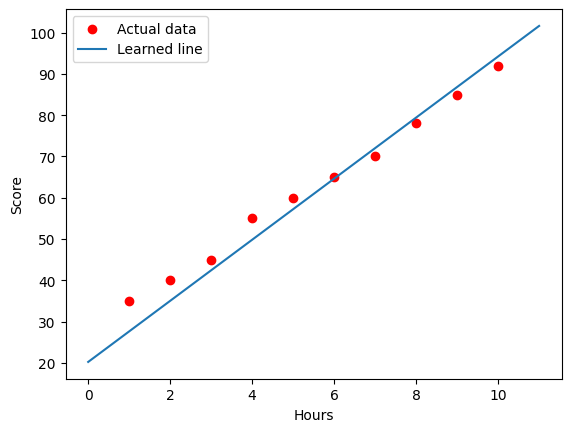

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt  # optional, for visualization

# Same tiny dataset
x = np.array([1,2,3,4,5,6,7,8,9,10], dtype=np.float32)
y = np.array([35,40,45,55,60,65,70,78,85,92], dtype=np.float32)

# Convert to PyTorch tensors and reshape to (N, 1)
x_tensor = torch.tensor(x).reshape(-1, 1)
y_tensor = torch.tensor(y).reshape(-1, 1)

# Define the model: single linear layer
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)   # input features=1, output features=1

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(x_tensor)
    loss = criterion(predictions, y_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Print final loss
print(f"\nFinal training loss: {loss.item():.4f}")

# Extract learned weight and bias
w = model.linear.weight.item()
b = model.linear.bias.item()
print(f"Learned weight: {w:.4f}")
print(f"Learned bias: {b:.4f}")

# Predict for 6.5 hours
unseen = torch.tensor([[6.5]], dtype=torch.float32)
model.eval()
with torch.no_grad():
    pred = model(unseen)
print(f"Predicted score for 6.5 hours: {pred.item():.2f}")

# Optional: plot the results
plt.scatter(x, y, color='red', label='Actual data')
x_line = np.linspace(0, 11, 100).reshape(-1, 1)
x_line_tensor = torch.tensor(x_line, dtype=torch.float32)
with torch.no_grad():
    y_line = model(x_line_tensor).numpy()
plt.plot(x_line, y_line, label='Learned line')
plt.xlabel('Hours')
plt.ylabel('Score')
plt.legend()
plt.show()

**Chapter 5 Backpropagation and Gradient Descent (No Fear)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Dataset: [hours studied, practice tests taken]
X = np.array([
    [1, 0], [2, 1], [3, 1], [4, 2], [5, 2],
    [6, 3], [7, 3], [8, 4], [9, 4], [10, 5]
], dtype=np.float32)

y = np.array([30, 38, 45, 52, 58, 64, 70, 78, 86, 92], dtype=np.float32).reshape(-1, 1)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)

# Define the model (2 inputs → 4 ReLU → 1 linear output)
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.output(x)
        return x

model = RegressionModel()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Manual training loop (500 epochs)
for epoch in range(1, 501):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, loss={loss.item():.2f}")

# Predict for a new student (6.5 hours, 3 tests)
new_student = torch.tensor([[6.5, 3]], dtype=torch.float32)
model.eval()
with torch.no_grad():
    predicted_score = model(new_student).item()
print(f"Predicted score: {predicted_score:.2f}")

Epoch 100, loss=452.77
Epoch 200, loss=381.29
Epoch 300, loss=380.03
Epoch 400, loss=380.01
Epoch 500, loss=380.01
Predicted score: 61.30


**Chapter 6 Your First Deep Learning Model in TensorFlow & Keras**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ---------------------------------------------------
# 1) RAW HARD-CODED DATA
# ---------------------------------------------------
# X = [size_sqft, bedrooms, age_years]
X = np.array([
    [1000, 2, 10],
    [ 850, 2, 12],
    [1200, 3, 8],
    [ 700, 2, 20],
    [1500, 3, 5],
    [2000, 4, 2]
], dtype=np.float32)

# y = price_lakhs
y = np.array([
    [75], [60], [95], [40], [140], [220]
], dtype=np.float32)

print("X shape:", X.shape)   # (6,3)
print("y shape:", y.shape)   # (6,1)

# ---------------------------------------------------
# 2) TRAIN/TEST SPLIT (first 4 train, last 2 test)
# ---------------------------------------------------
X_train, y_train = X[:4], y[:4]
X_test, y_test = X[4:], y[4:]

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

# ---------------------------------------------------
# 3) STANDARDIZATION (fit on train, transform both)
# ---------------------------------------------------
mean = X_train.mean(axis=0, keepdims=True)
std = X_train.std(axis=0, keepdims=True) + 1e-7   # avoid division by zero

X_train_s = (X_train - mean) / std
X_test_s  = (X_test - mean) / std

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

# ---------------------------------------------------
# 4) BUILD MODEL (PyTorch)
# ---------------------------------------------------
class HousePriceModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.net(x)

model = HousePriceModel()

# ---------------------------------------------------
# 5) LOSS, OPTIMIZER, METRIC
# ---------------------------------------------------
criterion = nn.MSELoss()          # MSE loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Helper to compute MAE
def mae(pred, target):
    return torch.abs(pred - target).mean().item()

# ---------------------------------------------------
# 6) TRAINING LOOP (300 epochs)
# ---------------------------------------------------
epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()

    # Optionally print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            train_mae = mae(predictions, y_train_t)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f}, MAE: {train_mae:.2f}")

print("\nTraining finished.")

# Final training loss & MAE
with torch.no_grad():
    final_pred = model(X_train_t)
    final_loss = criterion(final_pred, y_train_t).item()
    final_mae = mae(final_pred, y_train_t)
print(f"Final training loss: {final_loss:.2f}")
print(f"Final training mae : {final_mae:.2f}")

# ---------------------------------------------------
# 7) EVALUATE ON TEST SET
# ---------------------------------------------------
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t)
    test_loss = criterion(test_pred, y_test_t).item()
    test_mae = mae(test_pred, y_test_t)
print(f"\nTest MAE (lakhs): {test_mae:.2f}")

# ---------------------------------------------------
# 8) PREDICT ON A NEW UNSEEN HOUSE
# ---------------------------------------------------
new_house = np.array([[1100, 3, 9]], dtype=np.float32)
# Standardize using TRAIN mean/std
new_house_s = (new_house - mean) / std
new_house_t = torch.tensor(new_house_s, dtype=torch.float32)

with torch.no_grad():
    pred_price = model(new_house_t).item()
print(f"\nNew house prediction (lakhs): {pred_price:.2f}")

# ---------------------------------------------------
# 9) SAVE + LOAD (Deployment readiness)
# ---------------------------------------------------
# Save model state dict (recommended)
torch.save(model.state_dict(), "house_price_model.pth")
print("\nModel saved as 'house_price_model.pth'")

# Load model (need to recreate architecture first)
loaded_model = HousePriceModel()
loaded_model.load_state_dict(torch.load("house_price_model.pth"))
loaded_model.eval()

# Predict with loaded model
with torch.no_grad():
    pred2 = loaded_model(new_house_t).item()
print(f"Loaded model prediction (lakhs): {pred2:.2f}")

# (Optional) Save entire model (architecture + weights)
# torch.save(model, "house_price_model_full.pth")
# loaded_model_full = torch.load("house_price_model_full.pth")

X shape: (6, 3)
y shape: (6, 1)

Train shape: (4, 3) (4, 1)
Test shape : (2, 3) (2, 1)
Epoch [50/300] - Loss: 4540.7295, MAE: 63.28
Epoch [100/300] - Loss: 3019.0474, MAE: 44.14
Epoch [150/300] - Loss: 2094.8320, MAE: 27.69
Epoch [200/300] - Loss: 2002.4443, MAE: 25.36
Epoch [250/300] - Loss: 1932.0448, MAE: 24.61
Epoch [300/300] - Loss: 1852.6224, MAE: 23.82

Training finished.
Final training loss: 1850.92
Final training mae : 23.80

Test MAE (lakhs): 168.89

New house prediction (lakhs): 9.20

Model saved as 'house_price_model.pth'
Loaded model prediction (lakhs): 9.20


**Chapter 7 How a Neural Network Learns Ex - House Prices (Weights, Biases, and Prediction).**


MODEL SUMMARY:
HousePriceModel(
  (hidden): Linear(in_features=4, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 49

Starting training...
Epoch  10/200 - Loss: 62.975198
Epoch  20/200 - Loss: 55.052991
Epoch  30/200 - Loss: 45.387545
Epoch  40/200 - Loss: 34.501449
Epoch  50/200 - Loss: 24.055430
Epoch  60/200 - Loss: 15.348679
Epoch  70/200 - Loss: 8.923189
Epoch  80/200 - Loss: 4.823546
Epoch  90/200 - Loss: 2.583582
Epoch 100/200 - Loss: 1.520113
Epoch 110/200 - Loss: 1.096244
Epoch 120/200 - Loss: 0.929971
Epoch 130/200 - Loss: 0.860508
Epoch 140/200 - Loss: 0.823731
Epoch 150/200 - Loss: 0.790159
Epoch 160/200 - Loss: 0.759918
Epoch 170/200 - Loss: 0.730149
Epoch 180/200 - Loss: 0.699237
Epoch 190/200 - Loss: 0.668297
Epoch 200/200 - Loss: 0.638322

Training finished.
Best training loss: 0.638322

FINAL LEARNED PARAMETERS:
Hidden layer weights shape: (8, 4) (4 inputs -> 8 neurons)
Hidden layer

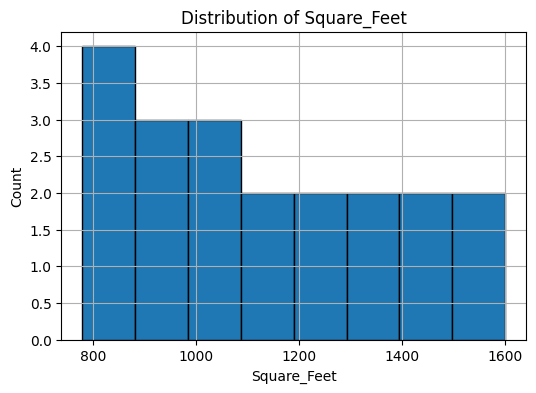

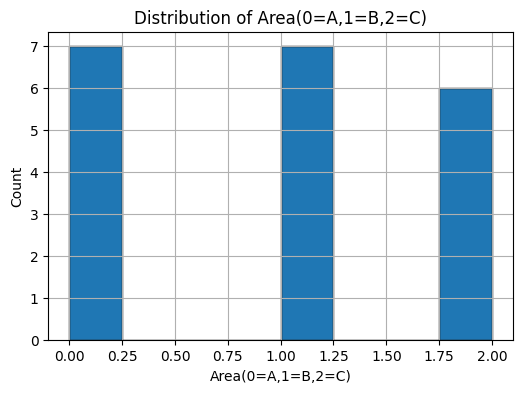

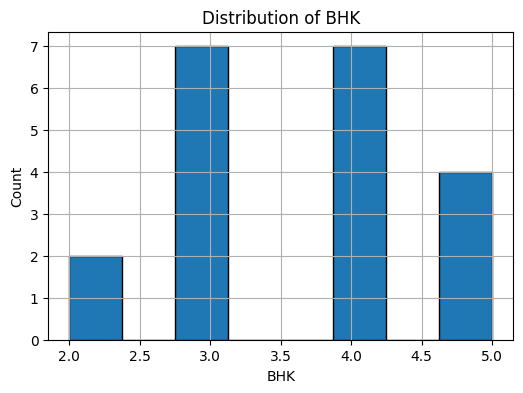

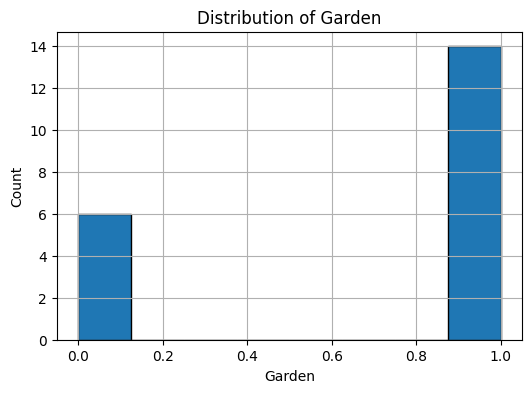

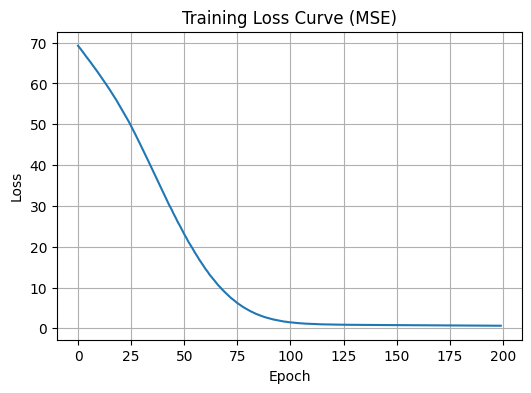

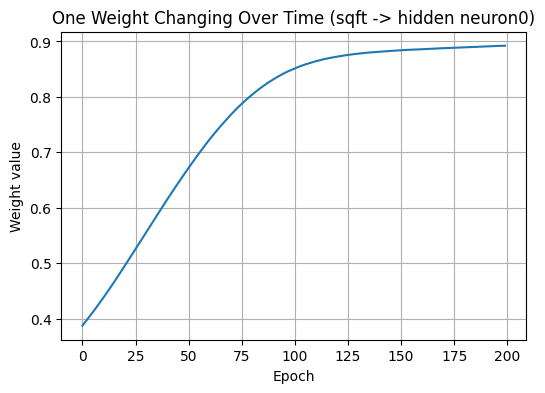

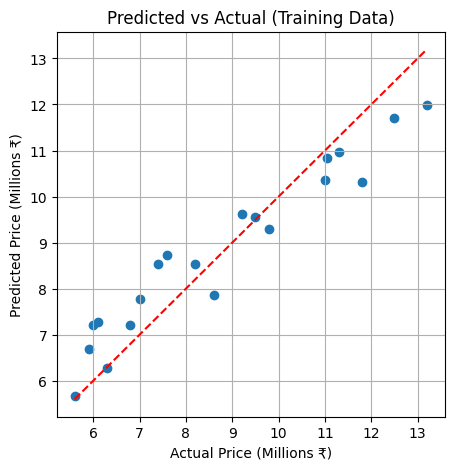

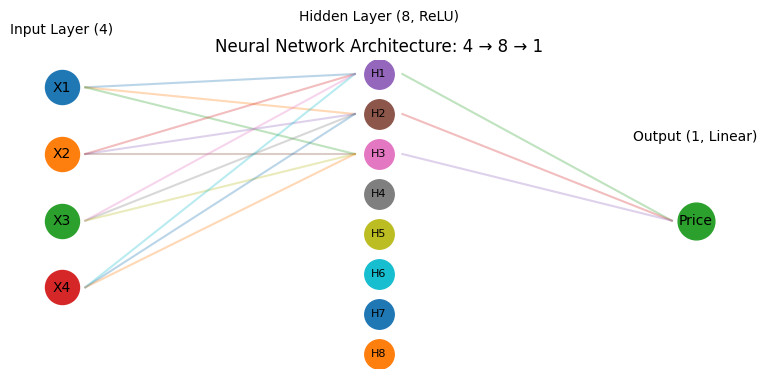


Model saved as: house_price_model.pth
Prediction using loaded model (House 3) ₹: 7,357,452.39


In [ ]:
"""
DEEP LEARNING HOUSE PRICE PREDICTION (REGRESSION) - PyTorch Version
What this program teaches:
1) Build a neural network to predict house price
2) What happens in training (Forward pass -> Loss -> Backprop -> Update)
3) How weights & biases change and get finalized
4) How trained weights are reused to predict unseen house
5) Graphs + architecture diagram
6) Save model and reload it for reuse
"""

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# 0) HARD-CODED TRAINING DATA (20 records)
# Encoding: Area A=0, B=1, C=2; Garden No=0, Yes=1
data = [
    # sqft, area, bhk, garden, price
    (1000, 0, 3, 1, 7000000),   # House 1 (exact)
    (800,  0, 3, 1, 6000000),   # House 2 (exact)
    (850,  0, 2, 0, 5600000),
    (900,  0, 3, 0, 6300000),
    (1100, 0, 4, 1, 8200000),
    (1200, 1, 4, 1, 9200000),
    (950,  1, 3, 0, 6800000),
    (1050, 1, 3, 1, 7600000),
    (1300, 1, 5, 1, 11000000),
    (1500, 2, 5, 1, 12500000),
    (1400, 2, 4, 1, 11300000),
    (1250, 2, 4, 0, 9800000),
    (1600, 2, 5, 1, 13200000),
    (780,  0, 2, 1, 5900000),
    (820,  0, 3, 1, 6100000),
    (1020, 1, 4, 0, 8600000),
    (1180, 1, 4, 1, 9500000),
    (1350, 2, 4, 1, 11050000),
    (1450, 2, 5, 0, 11800000),
    (980,  1, 3, 1, 7400000),
]

data = np.array(data, dtype=np.float32)
X = data[:, 0:4]          # features
y = data[:, 4:5]          # target as 2D (n,1)

# 1) NORMALIZATION (important for stable training)
X_norm = X.copy()
X_norm[:, 0] = X_norm[:, 0] / 1000.0    # sqft -> thousands
X_norm[:, 1] = X_norm[:, 1] / 2.0       # area 0..2 -> 0..1
X_norm[:, 2] = X_norm[:, 2] / 5.0       # bhk up to 5 -> 0..1
# garden stays 0/1

y_norm = y / 1_000_000.0                # price -> millions

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32)

# Create DataLoader for batch training (batch_size=4)
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# 2) MODEL DESIGN
class HousePriceModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 8)
        self.output = nn.Linear(8, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.output(x)
        return x

model = HousePriceModel()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nMODEL SUMMARY:")
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params}")

# 3) TRAINING LOOP WITH WEIGHT TRACKING AND EARLY STOPPING
class WeightHistory:
    """Track weight from first feature to first hidden neuron and losses."""
    def __init__(self):
        self.w00 = []    # weight from feature-0 (sqft) to hidden neuron-0
        self.losses = []

weight_hist = WeightHistory()

# Early stopping parameters
patience = 30
best_loss = float('inf')
patience_counter = 0
best_model_state = None

epochs = 200
print("\nStarting training...")
for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    epoch_loss /= len(dataset)   # average loss for the epoch

    # Record weight (sqft -> first hidden neuron) and loss
    with torch.no_grad():
        hidden_W = model.hidden.weight.detach().cpu().numpy()
        weight_hist.w00.append(hidden_W[0, 0])   # [neuron0, feature0]
        weight_hist.losses.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{epochs} - Loss: {epoch_loss:.6f}")

    # Early stopping check
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch} (loss did not improve for {patience} epochs)")
            # Restore best model
            model.load_state_dict(best_model_state)
            break

print("\nTraining finished.")
print(f"Best training loss: {best_loss:.6f}")

# 4) FINAL LEARNED PARAMETERS
hidden_W, hidden_b = model.hidden.weight.detach().cpu().numpy(), model.hidden.bias.detach().cpu().numpy()
out_W, out_b = model.output.weight.detach().cpu().numpy(), model.output.bias.detach().cpu().numpy()

print("\nFINAL LEARNED PARAMETERS:")
print(f"Hidden layer weights shape: {hidden_W.shape} (4 inputs -> 8 neurons)")
print(f"Hidden layer bias shape: {hidden_b.shape}")
print(f"Output layer weights shape: {out_W.shape} (8 -> 1)")
print(f"Output layer bias shape: {out_b.shape}")

print("\nSample weights (Hidden Neuron 0):")
print(f" Weight for sqft   : {hidden_W[0, 0]:.6f}")
print(f" Weight for area   : {hidden_W[0, 1]:.6f}")
print(f" Weight for bhk    : {hidden_W[0, 2]:.6f}")
print(f" Weight for garden : {hidden_W[0, 3]:.6f}")
print(f" Bias neuron0      : {hidden_b[0]:.6f}")

# 5) PREDICT ON SPECIFIC HOUSES (including unseen House3)
def normalize_house(house_array):
    h = house_array.copy()
    h[:, 0] /= 1000.0
    h[:, 1] /= 2.0
    h[:, 2] /= 5.0
    return h

house1 = np.array([[1000, 0, 3, 1]], dtype=np.float32)
house2 = np.array([[ 800, 0, 3, 1]], dtype=np.float32)
house3 = np.array([[ 850, 0, 3, 1]], dtype=np.float32)   # unseen

h1n = normalize_house(house1)
h2n = normalize_house(house2)
h3n = normalize_house(house3)

model.eval()
with torch.no_grad():
    pred_h3_million = model(torch.tensor(h3n, dtype=torch.float32)).item()
pred_h3_price = pred_h3_million * 1_000_000.0
print("\nUNSEEN HOUSE 3 PREDICTION:")
print("House 3: 850 sqft, Area A, 3 BHK, Garden Yes")
print(f"Predicted price (₹): {pred_h3_price:,.2f}")

# 6) MANUAL FORWARD PASS (demonstrate reuse of same weights)
# Using numpy to show the computation directly with stored weights
h3n_np = h3n  # already numpy array (1,4)

# Hidden layer: z1 = input * W_hidden^T + b_hidden
# Note: hidden_W shape = (8,4) because PyTorch Linear stores (out_features, in_features)
z1 = np.dot(h3n_np, hidden_W.T) + hidden_b   # (1,8)
a1 = np.maximum(0, z1)                       # ReLU activation

# Output layer: y_pred = a1 * W_output^T + b_output
# out_W shape = (1,8) -> we transpose for dot: (1,8) dot (8,1) -> (1,1)
z2 = np.dot(a1, out_W.T) + out_b             # (1,1)
pred_manual_million = z2[0, 0]
pred_manual_price = pred_manual_million * 1_000_000.0

print("\nMANUAL FORWARD PASS (same stored weights reused):")
print("Hidden layer output (8 neurons):", np.round(a1[0], 4))
print(f"Predicted price (₹) manual: {pred_manual_price:,.2f}")

# 7) PLOTS / GRAPHS

# 7.1 Feature distributions
feature_names = ["Square_Feet", "Area(0=A,1=B,2=C)", "BHK", "Garden"]
for i in range(4):
    plt.figure(figsize=(6,4))
    plt.hist(X[:, i], bins=8, edgecolor="black")
    plt.title(f"Distribution of {feature_names[i]}")
    plt.xlabel(feature_names[i])
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

# 7.2 Loss curve (MSE)
plt.figure(figsize=(6,4))
plt.plot(weight_hist.losses)
plt.title("Training Loss Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 7.3 Weight change (sqft -> hidden neuron 0)
plt.figure(figsize=(6,4))
plt.plot(weight_hist.w00)
plt.title("One Weight Changing Over Time (sqft -> hidden neuron0)")
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.grid(True)
plt.show()

# 7.4 Predicted vs Actual (on training data)
model.eval()
with torch.no_grad():
    pred_all = model(X_tensor).numpy().flatten()
actual_all = y_norm.flatten()

plt.figure(figsize=(5,5))
plt.scatter(actual_all, pred_all)
mn = min(actual_all.min(), pred_all.min())
mx = max(actual_all.max(), pred_all.max())
plt.plot([mn, mx], [mn, mx], 'r--')  # perfect line
plt.title("Predicted vs Actual (Training Data)")
plt.xlabel("Actual Price (Millions ₹)")
plt.ylabel("Predicted Price (Millions ₹)")
plt.grid(True)
plt.show()

# 8) DRAW SIMPLE NEURAL NETWORK DIAGRAM
def draw_network_diagram():
    plt.figure(figsize=(9,4))
    plt.axis("off")
    input_y = [3, 2, 1, 0]
    hidden_y = [3.2, 2.6, 2.0, 1.4, 0.8, 0.2, -0.4, -1.0]
    out_y = [1.0]

    # Input nodes
    for i, y0 in enumerate(input_y):
        plt.scatter(1, y0, s=600)
        plt.text(1, y0, f"X{i+1}", ha="center", va="center")
    plt.text(1, 3.8, "Input Layer (4)", ha="center")

    # Hidden nodes
    for i, y0 in enumerate(hidden_y):
        plt.scatter(5, y0, s=450)
        plt.text(5, y0, f"H{i+1}", ha="center", va="center", fontsize=8)
    plt.text(5, 4.0, "Hidden Layer (8, ReLU)", ha="center")

    # Output node
    plt.scatter(9, out_y[0], s=700)
    plt.text(9, out_y[0], "Price", ha="center", va="center")
    plt.text(9, 2.2, "Output (1, Linear)", ha="center")

    # Connections (simplified: only a few lines)
    for iy in input_y:
        for hy in hidden_y[:3]:
            plt.plot([1.3, 4.7], [iy, hy], alpha=0.3)
    for hy in hidden_y[:3]:
        plt.plot([5.3, 8.7], [hy, out_y[0]], alpha=0.3)

    plt.title("Neural Network Architecture: 4 → 8 → 1")
    plt.show()

draw_network_diagram()

# 9) SAVE AND LOAD MODEL (state_dict)
torch.save(model.state_dict(), "house_price_model.pth")
print("\nModel saved as: house_price_model.pth")

# Load the model
loaded_model = HousePriceModel()
loaded_model.load_state_dict(torch.load("house_price_model.pth"))
loaded_model.eval()

with torch.no_grad():
    pred_loaded_million = loaded_model(torch.tensor(h3n, dtype=torch.float32)).item()
pred_loaded_price = pred_loaded_million * 1_000_000.0
print(f"Prediction using loaded model (House 3) ₹: {pred_loaded_price:,.2f}")

**Chapter 8 Hyperparameters That Control Learning**

In [ ]:
import numpy as np
import tensorflow as tf

X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]], dtype=np.float32)
y = np.array([[35],[40],[45],[55],[60],[65],[70],[78],[85],[92]], dtype=np.float32)

def train_with_lr(lr):
    model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(1,))])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr), loss="mse")
    history = model.fit(X, y, epochs=200, batch_size=5, verbose=0)
    return history.history["loss"][-1]  # final loss

for lr in [0.001, 0.01, 0.1]:
    final_loss = train_with_lr(lr)
    print(f"learning_rate={lr} -> final loss={final_loss:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


learning_rate=0.001 -> final loss=109.20
learning_rate=0.01 -> final loss=6.44
learning_rate=0.1 -> final loss=nan


**Example 2 - Hyperparameter Fine-Tuning**

Starting training...
Epoch  10/50 - Loss: 3495229808.0000
Epoch  20/50 - Loss: 3125395216.0000
Epoch  30/50 - Loss: 1943011136.0000
Epoch  40/50 - Loss: 354964322.0000
Epoch  50/50 - Loss: 94618571.0000
Training finished. Best loss: 94618571.0000
Predicted rent (INR): 47481


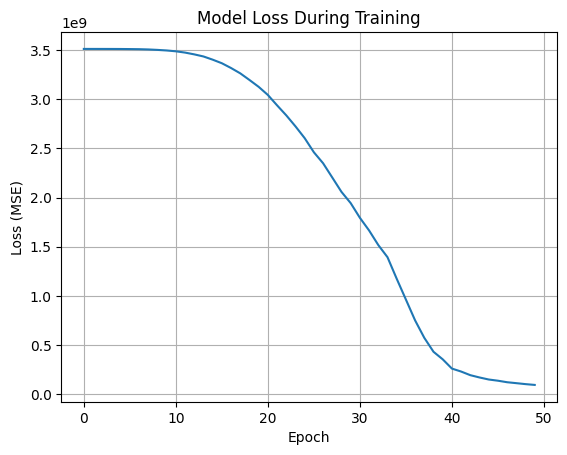

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# ---------- Data ----------
X = np.array([
    [650, 1, 12], [800, 2, 8], [900, 2, 5], [1100, 3, 6],
    [1200, 3, 2], [1500, 3, 1], [1700, 4, 3], [2000, 4, 2],
    [2400, 4, 1], [3000, 5, 4], [3500, 5, 2], [4000, 6, 1]
], dtype=np.float32)

y = np.array([
    18000, 23000, 26000, 32000, 36000, 42000,
    48000, 55000, 65000, 80000, 92000, 110000
], dtype=np.float32).reshape(-1, 1)

# ---------- Normalization ----------
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True) + 1e-8
Xn = (X - X_mean) / X_std

# Convert to PyTorch tensors
X_tensor = torch.tensor(Xn, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# DataLoader (batch size = 3)
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=3, shuffle=True)

# ---------- Model definition ----------
class RentPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 6)
        self.fc2 = nn.Linear(6, 3)
        self.fc3 = nn.Linear(3, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = RentPredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)   # lr = 0.1 as in original

# ---------- Early stopping ----------
best_loss = float('inf')
patience = 50
patience_counter = 0
best_model_state = None

epochs = 50   # initial max epochs (early stopping may cut earlier)
loss_history = []

print("Starting training...")
for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    epoch_loss /= len(dataset)   # average loss for the epoch
    loss_history.append(epoch_loss)

    # Early stopping check (on training loss)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            model.load_state_dict(best_model_state)
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{epochs} - Loss: {epoch_loss:.4f}")

print(f"Training finished. Best loss: {best_loss:.4f}")

# ---------- Prediction on new house ----------
new_house = np.array([[1400, 3, 2]], dtype=np.float32)
new_house_n = (new_house - X_mean) / X_std
new_house_t = torch.tensor(new_house_n, dtype=torch.float32)

model.eval()
with torch.no_grad():
    pred_rent = model(new_house_t).item()
print(f"Predicted rent (INR): {int(pred_rent)}")

# ---------- Plot training loss ----------
plt.plot(loss_history)
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

**Chapter 9 House Price Prediction with Deep Learning**

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
data = []

base_patterns = [
    {"sqft": 800, "area": 0, "bhk": 2, "garden": 0, "base_price": 3000000},
    {"sqft": 1000, "area": 0, "bhk": 3, "garden": 1, "base_price": 4500000},
    {"sqft": 1200, "area": 1, "bhk": 3, "garden": 0, "base_price": 5000000},
    {"sqft": 1500, "area": 2, "bhk": 5, "garden": 1, "base_price": 6500000},
]

for i in range(20):
    pattern = base_patterns[i % len(base_patterns)]
    sqft = pattern["sqft"] + np.random.randint(-80, 81)
    area = pattern["area"]
    bhk = pattern["bhk"]
    garden = pattern["garden"]
    # Price increases with square feet; add small random noise
    price = pattern["base_price"] + (sqft - pattern["sqft"]) * 5000
    price += np.random.randint(-200000, 200001)
    data.append([sqft, area, bhk, garden, price])

df = pd.DataFrame(data, columns=["Square_Feet", "Area", "BHK", "Garden", "Price"])
print(df.head(10))
print("Total Records:", len(df))

   Square_Feet  Area  BHK  Garden    Price
0          822     0    2       0  3056867
1         1012     0    3       1  4725838
2         1226     1    3       0  5049879
3         1440     2    5       1  6054886
4          841     0    2       0  3092498
5         1007     0    3       1  4723468
6         1219     1    3       0  5086335
7         1571     2    5       1  6696090
8          869     0    2       0  3209820
9          921     0    3       1  4226879
Total Records: 20


**Normalize features and target (fixed)**

In [ ]:
X = df[["Square_Feet", "Area", "BHK", "Garden"]].values
y = df["Price"].values

# IMPORTANT: convert to float before dividing
Xn = X.astype("float32")
Xn[:, 0] = Xn[:, 0] / 1000  # sqft
Xn[:, 1] = Xn[:, 1] / 2     # area (0..2)
Xn[:, 2] = Xn[:, 2] / 5     # bhk (assume max 5)
# Garden stays 0/1

yn = y.astype("float32") / 1_000_000  # price in millions

print("First 3 normalized rows:")
print(Xn[:3], yn[:3])

First 3 normalized rows:
[[0.822 0.    0.4   0.   ]
 [1.012 0.    0.6   1.   ]
 [1.226 0.5   0.6   0.   ]] [3.056867 4.725838 5.049879]


**Build and compile the model**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(8, activation="relu", input_shape=(4,), name="hidden_layer"),
    layers.Dense(1, activation="linear", name="output_layer")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

**Train with EarlyStopping**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    Xn, yn, test_size=0.2, random_state=42
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 30.7590 - mae: 5.3678 - val_loss: 28.0251 - val_mae: 5.1386
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 30.3235 - mae: 5.3305 - val_loss: 27.6145 - val_mae: 5.1023
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 29.9402 - mae: 5.2967 - val_loss: 27.1936 - val_mae: 5.0649
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 29.4839 - mae: 5.2583 - val_loss: 26.7875 - val_mae: 5.0285
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 29.0956 - mae: 5.2242 - val_loss: 26.3915 - val_mae: 4.9926
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 28.6975 - mae: 5.1893 - val_loss: 26.0314 - val_mae: 4.9593
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 28.3102 - mae: 5.1558 - val_loss: 25.7101 - val_mae: 4.9290
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 27.9943 - mae: 5.1265 - val_loss: 25.4173 - val_mae: 4.9010
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - los

**Inference (Prediction on New Data)**

In [ ]:
import numpy as np

house = np.array([[850, 0, 3, 1]], dtype="float32")
# Apply the same normalization
house[:, 0] = house[:, 0] / 1000
house[:, 1] = house[:, 1] / 2
house[:, 2] = house[:, 2] / 5

pred_million = float(model.predict(house)[0][0])
pred_inr = pred_million * 1_000_000

print("Predicted price (million):", pred_million)
print("Predicted price (INR):", int(pred_inr))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted price (million): 2.577815055847168
Predicted price (INR): 2577815


**Save and Reuse**

In [ ]:
# Save in the new recommended format
model.save("house_price_model.keras")

# Load with custom objects
loaded_model = keras.models.load_model("house_price_model.keras")
pred_million_2 = float(loaded_model.predict(house)[0][0])
print("Loaded model prediction (INR):", int(pred_million_2 * 1_000_000))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Loaded model prediction (INR): 2577815


**Chapter 10 ANN Regression Example (Real Estate Rent Prediction)**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Tiny real-estate dataset (12 rows)
# Features: [area_sqft, bedrooms, age_years]
X = np.array([
    [650, 1, 12], [800, 2, 8], [900, 2, 5], [1100, 3, 6],
    [1200, 3, 2], [1500, 3, 1], [1700, 4, 3], [2000, 4, 2],
    [2400, 4, 1], [3000, 5, 4], [3500, 5, 2], [4000, 6, 1],
], dtype=np.float32)

# Target: monthly rent (INR) - simple realistic-looking numbers
y = np.array([
    18000, 23000, 26000, 32000, 36000, 42000,
    48000, 55000, 65000, 80000, 92000, 110000
], dtype=np.float32)

# ---- Normalize features (mean 0, std 1) ----
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
Xn = (X - X_mean) / X_std

model = keras.Sequential([
    keras.layers.Dense(8, activation="relu", input_shape=(3,)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1)  # rent
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")
model.fit(Xn, y, epochs=500, batch_size=4, verbose=0)

# Predict unseen property
new_house = np.array([[1400, 3, 4]], dtype=np.float32)
new_house_n = (new_house - X_mean) / X_std
pred_rent = model.predict(new_house_n, verbose=0)[0][0]
print("Predicted rent (INR):", int(pred_rent))

Predicted rent (INR): 24392


**Chapter 11 ANN Classification Example (Banking Default Risk)**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Features: [income_lakhs, loan_lakhs, credit_score, late_payments]
X = np.array([
    [6, 2, 750, 0], [5, 4, 720, 1], [4, 6, 680, 2], [3, 7, 650, 3],
    [10, 3, 790, 0], [8, 8, 700, 2], [12, 5, 800, 0], [2.5, 6, 620, 4],
    [7, 9, 690, 2], [15, 4, 810, 0], [9, 12, 660, 3], [11, 10, 710, 1],
    [3, 5, 640, 3], [13, 6, 780, 0]
], dtype=np.float32)

# Label: 1 = default risk high, 0 = low
y = np.array([0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0], dtype=np.float32)

# Normalize
mean = X.mean(axis=0)
std = X.std(axis=0) + 1e-8
Xn = (X - mean) / std

model = keras.Sequential([
    keras.layers.Dense(8, activation="relu", input_shape=(4,)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")  # probability
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.fit(Xn, y, epochs=400, batch_size=4, verbose=0)

# Predict new applicant
new_app = np.array([[6.5, 7, 670, 2]], dtype=np.float32)
new_app_n = (new_app - mean) / std
p = model.predict(new_app_n, verbose=0)[0][0]

print("Default risk probability:", float(p))
print("Decision (threshold 0.5):", "High Risk" if p >= 0.5 else "Low Risk")

Default risk probability: 0.37753748893737793
Decision (threshold 0.5): Low Risk


**Chapter 11.1 TensorFlow & Keras - How They Work Inside, and How You Build Real AI Models**

In [ ]:
import numpy as np
import tensorflow as tf

# -----------------------------
# 1) HARD-CODED DATA
# X = [size, bedrooms, age]
# y = price (lakhs)
# -----------------------------
X = np.array([
    [1000, 2, 10],
    [850, 2, 12],
    [1200, 3, 8],
    [700, 2, 20],
    [1500, 3, 5],
    [2000, 4, 2]
], dtype=np.float32)

y = np.array([
    [75], [60], [95], [40], [140], [220]
], dtype=np.float32)

# -----------------------------
# 2) TRAIN/TEST SPLIT
# -----------------------------
X_train, y_train = X[:4], y[:4]
X_test, y_test = X[4:], y[4:]

# -----------------------------
# 3) STATS: STANDARDIZATION
# x' = (x - mean) / std
# train stats only
# -----------------------------
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-7
X_train_s = (X_train - mean) / std
X_test_s = (X_test - mean) / std

# -----------------------------
# 4) MODEL
# -----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)  # regression output
])

# -----------------------------
# 5) COMPILE + TRAIN
# -----------------------------
model.compile(optimizer=tf.keras.optimizers.Adam(0.01),
              loss="mse",
              metrics=["mae"])
model.fit(X_train_s, y_train, epochs=300, verbose=0)

# -----------------------------
# 6) EVALUATE + PREDICT
# -----------------------------
test_loss, test_mae = model.evaluate(X_test_s, y_test, verbose=0)
print("Regression Test MAE (lakhs):", round(float(test_mae), 2))

new_house = np.array([[1100, 3, 9]], dtype=np.float32)
new_house_s = (new_house - mean) / std
pred = model.predict(new_house_s, verbose=0)
print("Predicted price (lakhs):", round(float(pred[0][0]), 2))

Regression Test MAE (lakhs): 177.11
Predicted price (lakhs): 2.97


**Part B: Example 2 (Classification) Predict Yes/No (Loan Default)**

In [ ]:
import numpy as np
import tensorflow as tf

# -------------------------------------------------------
# 1) HARD-CODED DATA
# X = [income_lakhs, credit_score, missed_payments]
# y = default (0/1)
# -------------------------------------------------------
X = np.array([
    [12, 780, 0],   # strong profile -> no default
    [10, 720, 1],   # mostly good
    [8, 680, 1],
    [6, 620, 2],
    [5, 590, 3],    # risky -> default
    [4, 560, 4],    # risky
], dtype=np.float32)

y = np.array([[0], [0], [0], [1], [1], [1]], dtype=np.float32)

# -------------------------------------------------------
# 2) TRAIN/TEST SPLIT
# -------------------------------------------------------
X_train, y_train = X[:4], y[:4]
X_test, y_test = X[4:], y[4:]

# -------------------------------------------------------
# 3) STATS: STANDARDIZATION (best practice)
# -------------------------------------------------------
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-7
X_train_s = (X_train - mean) / std
X_test_s = (X_test - mean) / std

# -------------------------------------------------------
# 4) MODEL (Sigmoid output)
# -------------------------------------------------------
clf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")   # probability
])

# -------------------------------------------------------
# 5) COMPILE + TRAIN
# loss = binary crossentropy (BCE)
# -------------------------------------------------------
clf.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
clf.fit(X_train_s, y_train, epochs=300, verbose=0)

# -------------------------------------------------------
# 6) EVALUATE + PREDICT
# -------------------------------------------------------
loss, acc = clf.evaluate(X_test_s, y_test, verbose=0)
print("\nClassification Test Accuracy:", round(float(acc), 2))

# Predict probability for new customer
new_customer = np.array([[7, 650, 2]], dtype=np.float32)
new_customer_s = (new_customer - mean) / std
prob = clf.predict(new_customer_s, verbose=0)[0][0]
prediction = 1 if prob >= 0.5 else 0
print("Default probability:", round(float(prob), 3))
print("Predicted class (0=No,1=Yes):", prediction)


Classification Test Accuracy: 1.0
Default probability: 0.988
Predicted class (0=No,1=Yes): 1


**Regression: Print Weights Before vs After Training (Hardcoded)**

In [ ]:
import numpy as np
import tensorflow as tf

# -----------------------------
# HARD-CODED DATA (Regression)
X = np.array([
    [1000, 2, 10],
    [850, 2, 12],
    [1200, 3, 8],
    [700, 2, 20],
    [1500, 3, 5],
    [2000, 4, 2]
], dtype=np.float32)

y = np.array([
    [75], [60], [95], [40], [140], [220]
], dtype=np.float32)

# Train/test split
X_train, y_train = X[:4], y[:4]

# Standardize using train stats
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-7
X_train_s = (X_train - mean) / std

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(8, activation="relu", name="hidden"),
    tf.keras.layers.Dense(1, name="output")
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="mse")

# -----------------------------
# PRINT WEIGHTS BEFORE TRAINING
print("=== BEFORE TRAINING ===")
for layer in model.layers:
    w = layer.get_weights()
    if w:
        W, b = w
        print(f"{layer.name}: W shape={W.shape}, b shape={b.shape}")
        print(" W first row:", np.round(W[0], 4))
        print(" b:", np.round(b, 4))

# Train
model.fit(X_train_s, y_train, epochs=300, verbose=0)

# -----------------------------
# PRINT WEIGHTS AFTER TRAINING
print("\n=== AFTER TRAINING ===")
for layer in model.layers:
    w = layer.get_weights()
    if w:
        W, b = w
        print(f"{layer.name}: W shape={W.shape}, b shape={b.shape}")
        print(" W first row:", np.round(W[0], 4))
        print(" b:", np.round(b, 4))

=== BEFORE TRAINING ===
hidden: W shape=(3, 8), b shape=(8,)
 W first row: [-0.4317 -0.2395  0.4611 -0.5052 -0.724  -0.1814  0.294   0.0024]
 b: [0. 0. 0. 0. 0. 0. 0. 0.]
output: W shape=(8, 1), b shape=(1,)
 W first row: [-0.3948]
 b: [0.]

=== AFTER TRAINING ===
hidden: W shape=(3, 8), b shape=(8,)
 W first row: [-0.3313 -0.4144  0.1434  1.586  -3.494   1.7465  0.1105  2.1542]
 b: [-0.243  -0.2704 -0.2874  3.0762  3.3868  3.0918 -0.3479  3.417 ]
output: W shape=(8, 1), b shape=(1,)
 W first row: [-0.2123]
 b: [1.9571]


**Classification: Print Weights + Show Probability Change (Hardcoded)**

In [ ]:
import numpy as np
import tensorflow as tf

# --------------------------------
# HARD-CODED DATA (Classification)
# --------------------------------
X = np.array([
    [12, 780, 0],
    [10, 720, 1],
    [8, 680, 1],
    [6, 620, 2],
    [5, 590, 3],
    [4, 560, 4],
], dtype=np.float32)

y = np.array([[0], [0], [0], [1], [1], [1]], dtype=np.float32)

# Train part only
X_train, y_train = X[:4], y[:4]

# Standardize
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-7
X_train_s = (X_train - mean) / std

# New customer to test probability
new_customer = np.array([[7, 650, 2]], dtype=np.float32)
new_customer_s = (new_customer - mean) / std

# Model
clf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(8, activation="relu", name="hidden"),
    tf.keras.layers.Dense(1, activation="sigmoid", name="output")
])

clf.compile(optimizer=tf.keras.optimizers.Adam(0.01),
            loss="binary_crossentropy",
            metrics=["accuracy"])

# ---------------------------------------
# PROBABILITY BEFORE TRAINING (random)
# ---------------------------------------
prob_before = clf.predict(new_customer_s, verbose=0)[0][0]
print("Probability BEFORE training:", round(float(prob_before), 3))

# Print weights before training
print("\n=== BEFORE TRAINING WEIGHTS ===")
for layer in clf.layers:
    w = layer.get_weights()
    if w:
        W, b = w
        print(f"{layer.name}: W mean={W.mean():.4f}, b mean={b.mean():.4f}")

# Train
clf.fit(X_train_s, y_train, epochs=300, verbose=0)

# ---------------------------------------
# PROBABILITY AFTER TRAINING (learned)
# ---------------------------------------
prob_after = clf.predict(new_customer_s, verbose=0)[0][0]
print("\nProbability AFTER training:", round(float(prob_after), 3))

# Print weights after training
print("\n=== AFTER TRAINING WEIGHTS ===")
for layer in clf.layers:
    w = layer.get_weights()
    if w:
        W, b = w
        print(f"{layer.name}: W mean={W.mean():.4f}, b mean={b.mean():.4f}")

# Final class
pred_class = 1 if prob_after >= 0.5 else 0
print("\nPredicted class (0=No default, 1=Default):", pred_class)

Probability BEFORE training: 0.337

=== BEFORE TRAINING WEIGHTS ===
hidden: W mean=-0.0892, b mean=0.0000
output: W mean=-0.1282, b mean=0.0000

Probability AFTER training: 0.983

=== AFTER TRAINING WEIGHTS ===
hidden: W mean=-0.1452, b mean=0.3942
output: W mean=-0.1757, b mean=-0.8265

Predicted class (0=No default, 1=Default): 1


**Chapter 12 CNN (Convolutional Neural Network) with MNIST**

**A tiny “manual” convolution to understand the sliding window (NumPy)**

In [ ]:
import numpy as np

# 5x5 grayscale "image"
img = np.array([
    [0, 0, 0, 0, 0],
    [0, 10, 10, 10, 0],
    [0, 10, 50, 10, 0],
    [0, 10, 10, 10, 0],
    [0, 0, 0, 0, 0]
], dtype=float)

# 3x3 edge-like filter (example)
kernel = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=float)

def conv2d_valid(image, kernel):
    H, W = image.shape
    kH, kW = kernel.shape
    outH = H - kH + 1
    outW = W - kW + 1
    out = np.zeros((outH, outW))
    for i in range(outH):
        for j in range(outW):
            patch = image[i:i+kH, j:j+kW]
            out[i, j] = np.sum(patch * kernel)  # dot product
    return out

out = conv2d_valid(img, kernel)

print("Input:\n", img)
print("\nKernel:\n", kernel)
print("\nFeature map output:\n", out)

Input:
 [[ 0.  0.  0.  0.  0.]
 [ 0. 10. 10. 10.  0.]
 [ 0. 10. 50. 10.  0.]
 [ 0. 10. 10. 10.  0.]
 [ 0.  0.  0.  0.  0.]]

Kernel:
 [[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]

Feature map output:
 [[ 60.  70.  60.]
 [  0.   0.   0.]
 [-60. -70. -60.]]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the model...
Epoch 1/2
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.7869 - loss: 0.7789 - val_accuracy: 0.9250 - val_loss: 0.2473
Epoch 2/2
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9473 - loss: 0.1866 - val_accuracy: 0.9450 - val_loss: 0.1704

Test accuracy: 0.9469

TESTING UNSEEN RECORDS FROM TEST SET

PREDICTION RESULTS
Test image index: 0
True label: 7
Predicted label: 7
Confidence: 99.98%

Prediction probabilities:
 Digit 0:   0.00%
 Digit 1:   0.00%
 Digit 2:   0.00%
 Digit 3:   0.02%
 Digit 4:   0.00%
 Digit 5:   0.00%
 Digit 6:   0.00%
 Digit 7:  99.98%
 Digit 8:   0.00%
 Digit 9:   0.00%


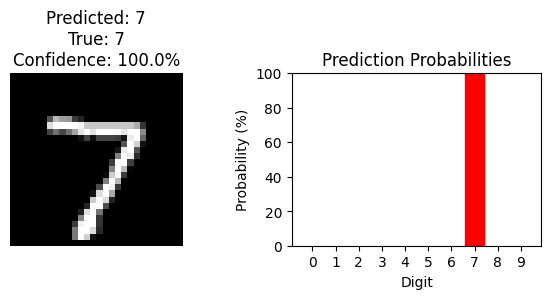


PREDICTION RESULTS
Test image index: 123
True label: 6
Predicted label: 6
Confidence: 99.87%

Prediction probabilities:
 Digit 0:   0.02%
 Digit 1:   0.00%
 Digit 2:   0.03%
 Digit 3:   0.01%
 Digit 4:   0.02%
 Digit 5:   0.03%
 Digit 6:  99.87%
 Digit 7:   0.00%
 Digit 8:   0.03%
 Digit 9:   0.00%


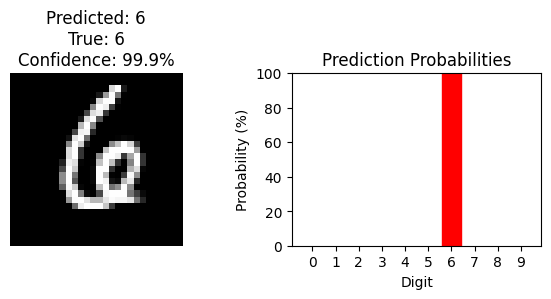


PREDICTION RESULTS
Test image index: 456
True label: 2
Predicted label: 2
Confidence: 92.77%

Prediction probabilities:
 Digit 0:   0.15%
 Digit 1:   3.09%
 Digit 2:  92.77%
 Digit 3:   2.17%
 Digit 4:   0.00%
 Digit 5:   0.07%
 Digit 6:   0.01%
 Digit 7:   0.31%
 Digit 8:   1.38%
 Digit 9:   0.05%


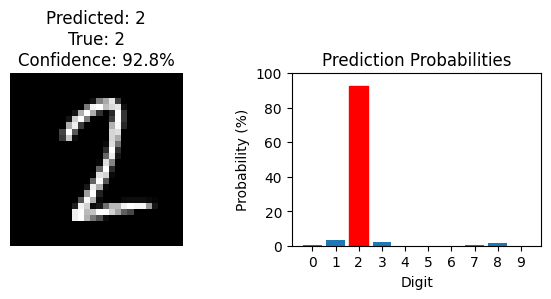


PREDICTION RESULTS
Test image index: 789
True label: 4
Predicted label: 4
Confidence: 90.38%

Prediction probabilities:
 Digit 0:   0.03%
 Digit 1:   0.01%
 Digit 2:   0.06%
 Digit 3:   0.09%
 Digit 4:  90.38%
 Digit 5:   0.01%
 Digit 6:   0.11%
 Digit 7:   1.88%
 Digit 8:   0.16%
 Digit 9:   7.28%


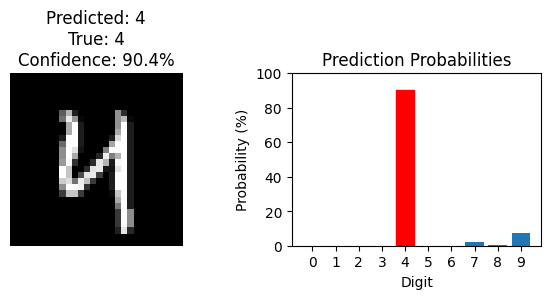


PREDICTION RESULTS
Test image index: 42
True label: 4
Predicted label: 4
Confidence: 95.92%

Prediction probabilities:
 Digit 0:   0.00%
 Digit 1:   0.01%
 Digit 2:   0.00%
 Digit 3:   0.03%
 Digit 4:  95.92%
 Digit 5:   0.00%
 Digit 6:   0.00%
 Digit 7:   0.55%
 Digit 8:   0.02%
 Digit 9:   3.46%


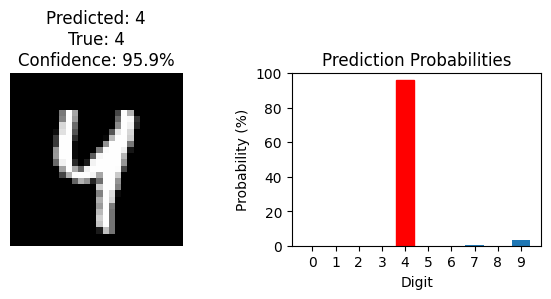


TESTING RANDOM UNSEEN RECORDS

PREDICTION RESULTS
Test image index: 3556
True label: 5
Predicted label: 5
Confidence: 98.24%

Prediction probabilities:
 Digit 0:   0.03%
 Digit 1:   0.00%
 Digit 2:   0.00%
 Digit 3:   0.18%
 Digit 4:   0.00%
 Digit 5:  98.24%
 Digit 6:   0.02%
 Digit 7:   1.05%
 Digit 8:   0.32%
 Digit 9:   0.15%


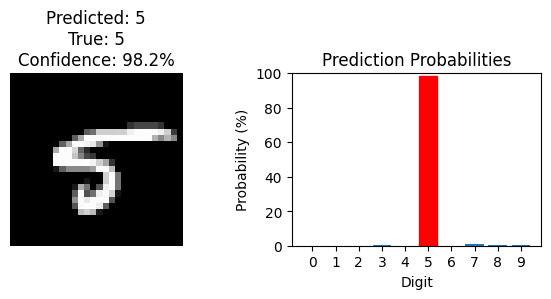


PREDICTION RESULTS
Test image index: 3890
True label: 5
Predicted label: 5
Confidence: 98.28%

Prediction probabilities:
 Digit 0:   0.00%
 Digit 1:   0.00%
 Digit 2:   0.00%
 Digit 3:   1.22%
 Digit 4:   0.00%
 Digit 5:  98.28%
 Digit 6:   0.00%
 Digit 7:   0.00%
 Digit 8:   0.48%
 Digit 9:   0.02%


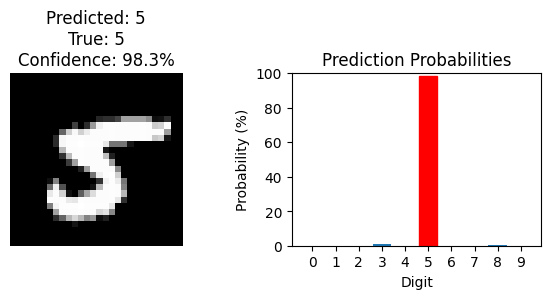


PREDICTION RESULTS
Test image index: 8838
True label: 2
Predicted label: 2
Confidence: 99.99%

Prediction probabilities:
 Digit 0:   0.00%
 Digit 1:   0.00%
 Digit 2:  99.99%
 Digit 3:   0.00%
 Digit 4:   0.00%
 Digit 5:   0.00%
 Digit 6:   0.00%
 Digit 7:   0.00%
 Digit 8:   0.00%
 Digit 9:   0.00%


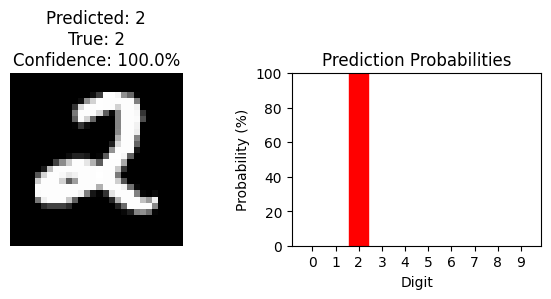


TESTING CUSTOM IMAGE

PREDICTION RESULTS
Predicted label: 3
Confidence: 66.29%

Prediction probabilities:
 Digit 0:   0.21%
 Digit 1:   0.04%
 Digit 2:  18.87%
 Digit 3:  66.29%
 Digit 4:   0.00%
 Digit 5:   1.36%
 Digit 6:   0.00%
 Digit 7:   7.40%
 Digit 8:   5.52%
 Digit 9:   0.32%


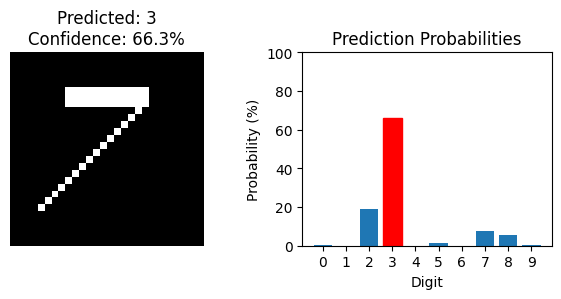


INTERACTIVE TESTING
Enter image indices from test set (0-9999)
Type 'r' for random, 'c' for custom, or 'q' to quit

Enter image index (0-9999) or command: exit
Invalid input. Please enter a number or command (r/c/q)

Enter image index (0-9999) or command: 0

PREDICTION RESULTS
Test image index: 0
True label: 7
Predicted label: 7
Confidence: 99.98%

Prediction probabilities:
 Digit 0:   0.00%
 Digit 1:   0.00%
 Digit 2:   0.00%
 Digit 3:   0.02%
 Digit 4:   0.00%
 Digit 5:   0.00%
 Digit 6:   0.00%
 Digit 7:  99.98%
 Digit 8:   0.00%
 Digit 9:   0.00%


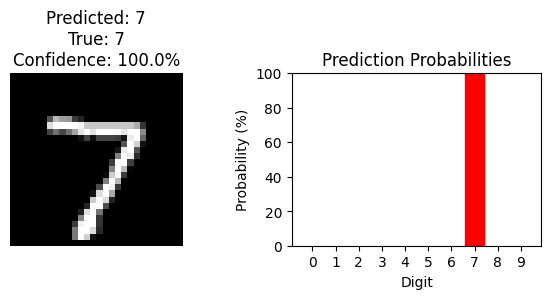


Enter image index (0-9999) or command: 8

PREDICTION RESULTS
Test image index: 8
True label: 5
Predicted label: 5
Confidence: 95.60%

Prediction probabilities:
 Digit 0:   0.07%
 Digit 1:   0.00%
 Digit 2:   0.07%
 Digit 3:   0.05%
 Digit 4:   0.01%
 Digit 5:  95.60%
 Digit 6:   3.39%
 Digit 7:   0.02%
 Digit 8:   0.14%
 Digit 9:   0.65%


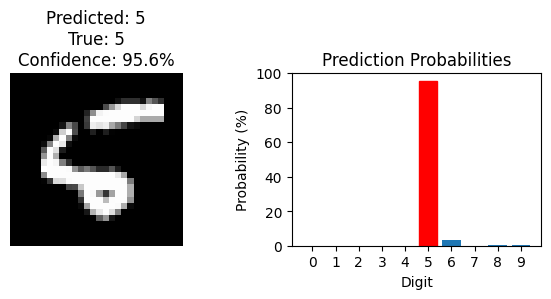


Enter image index (0-9999) or command: r

PREDICTION RESULTS
Test image index: 5393
True label: 4
Predicted label: 4
Confidence: 99.95%

Prediction probabilities:
 Digit 0:   0.00%
 Digit 1:   0.00%
 Digit 2:   0.00%
 Digit 3:   0.00%
 Digit 4:  99.95%
 Digit 5:   0.00%
 Digit 6:   0.00%
 Digit 7:   0.00%
 Digit 8:   0.00%
 Digit 9:   0.04%


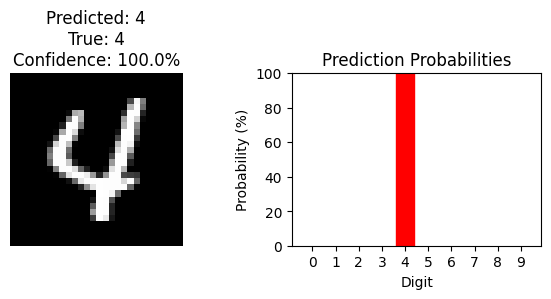


Enter image index (0-9999) or command: exit
Invalid input. Please enter a number or command (r/c/q)

Enter image index (0-9999) or command: Q
Exiting...


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to 0-1 and add channel dimension (28,28,1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train[..., None]   # Add channel dimension
x_test = x_test[..., None]

# Use a small subset for faster training
x_train_small = x_train[:10000]
y_train_small = y_train[:10000]

# Build the model
model = keras.Sequential([
    keras.layers.Conv2D(16, (3,3), activation="relu", input_shape=(28,28,1)),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Conv2D(32, (3,3), activation="relu"),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
print("Training the model...")
model.fit(x_train_small, y_train_small,
          epochs=2, batch_size=64, validation_split=0.1)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")

# ===========================================
# NEW: Function to test unseen records
# ===========================================
def test_unseen_record(model, image_index=None, custom_image=None):
    """
    Test an unseen record (either from test set or custom image)

    Args:
        model: Trained CNN model
        image_index: Index of image from test set (0-9999)
        custom_image: Custom 28x28 numpy array (0-255 or 0-1 normalized)
    """
    if custom_image is not None:
        # Handle custom image
        if custom_image.max() > 1.0:        # Assume 0-255 range, normalize to 0-1
            image = custom_image.astype("float32") / 255.0
        else:
            image = custom_image.astype("float32")
        # Ensure correct shape (28, 28, 1)
        if len(image.shape) == 2:
            image = image[..., None]
        elif len(image.shape) == 3 and image.shape[2] != 1:
            # Convert RGB to grayscale if needed
            image = np.mean(image, axis=2, keepdims=True)
        # Add batch dimension
        image_batch = np.expand_dims(image, axis=0)
        true_label = "Custom image (no true label)"

    elif image_index is not None:
        # Use image from test set
        if image_index < 0 or image_index >= len(x_test):
            print(f"Error: image_index must be between 0 and {len(x_test)-1}")
            return
        image = x_test[image_index]
        image_batch = np.expand_dims(image, axis=0)
        true_label = y_test[image_index]
    else:
        print("Error: Either image_index or custom_image must be provided")
        return

    # Make prediction
    predictions = model.predict(image_batch, verbose=0)
    predicted_label = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    # Display results
    print("\n" + "="*50)
    print("PREDICTION RESULTS")
    print("="*50)
    if custom_image is None:
        print(f"Test image index: {image_index}")
        print(f"True label: {true_label}")
    print(f"Predicted label: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")

    print("\nPrediction probabilities:")
    for i, prob in enumerate(predictions[0]):
        print(f" Digit {i}: {prob*100:6.2f}%")

    # Visualize the image
    plt.figure(figsize=(6, 3))

    # Show image
    plt.subplot(1, 2, 1)
    if custom_image is not None:
        plt.imshow(custom_image.squeeze(), cmap='gray')
    else:
        plt.imshow(x_test[image_index].squeeze(), cmap='gray')
    title = f"Predicted: {predicted_label}"
    if custom_image is None:
        title += f"\nTrue: {true_label}"
    title += f"\nConfidence: {confidence:.1f}%"
    plt.title(title)
    plt.axis('off')

    # Show prediction probabilities as bar chart
    plt.subplot(1, 2, 2)
    bars = plt.bar(range(10), predictions[0] * 100)
    bars[predicted_label].set_color('red')
    plt.xlabel('Digit')
    plt.ylabel('Probability (%)')
    plt.title('Prediction Probabilities')
    plt.xticks(range(10))
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# Example 1: Test specific images from test set
print("\n" + "="*50)
print("TESTING UNSEEN RECORDS FROM TEST SET")
print("="*50)

# Test a few specific images
test_indices = [0, 123, 456, 789, 42]   # You can change these
for idx in test_indices:
    test_unseen_record(model, image_index=idx)

# Example 2: Test random images
print("\n" + "="*50)
print("TESTING RANDOM UNSEEN RECORDS")
print("="*50)

for i in range(3):
    random_idx = np.random.randint(0, len(x_test))
    test_unseen_record(model, image_index=random_idx)

# Example 3: Test custom image
print("\n" + "="*50)
print("TESTING CUSTOM IMAGE")
print("="*50)

# Create a simple custom "7" image
# You can replace this with your own 28x28 image
custom_digit = np.zeros((28, 28))
# Draw a simple "7"
custom_digit[5:8, 8:20] = 1.0          # Horizontal line
for i in range(15):
    custom_digit[8+i, 18-i] = 1.0      # Diagonal line

# Test the custom image
test_unseen_record(model, custom_image=custom_digit)

# Interactive testing loop
print("\n" + "="*50)
print("INTERACTIVE TESTING")
print("="*50)
print("Enter image indices from test set (0-9999)")
print("Type 'r' for random, 'c' for custom, or 'q' to quit")

while True:
    user_input = input("\nEnter image index (0-9999) or command: ").strip().lower()
    if user_input == 'q':
        print("Exiting...")
        break
    elif user_input == 'r':
        random_idx = np.random.randint(0, len(x_test))
        test_unseen_record(model, image_index=random_idx)
    elif user_input == 'c':
        # Create another custom digit (a simple "4")
        custom_img = np.zeros((28, 28))
        # Vertical line
        custom_img[5:20, 10:13] = 1.0
        # Horizontal line
        custom_img[15:18, 5:15] = 1.0
        # Diagonal
        for i in range(10):
            custom_img[5+i, 15-i] = 1.0
        test_unseen_record(model, custom_image=custom_img)
    else:
        try:
            idx = int(user_input)
            if 0 <= idx < len(x_test):
                test_unseen_record(model, image_index=idx)
            else:
                print(f"Please enter a number between 0 and {len(x_test)-1}")
        except ValueError:
            print("Invalid input. Please enter a number or command (r/c/q)")

**Chapter 13 RNN/LSTM (Sequence Learning) with a Tiny Example**

In [ ]:
import numpy as np
import tensorflow as tf

# ---------------------------------------------------------
# 1) Hard-coded Sequence Data (20 records)
# Each record = 5 time steps
# Label: 0 = normal, 1 = risky
# ---------------------------------------------------------
X = np.array([
    [120, 130, 110, 140, 125], [100, 105, 98, 110, 102],
    [150, 140, 160, 155, 145], [90, 95, 92, 88, 94],
    [200, 210, 190, 205, 195], [120, 125, 130, 400, 450],
    [300, 320, 310, 305, 315], [90, 500, 520, 510, 530],
    [250, 260, 270, 280, 290], [110, 115, 120, 125, 600],
    [130, 128, 135, 132, 129], [95, 98, 100, 99, 97],
    [160, 155, 158, 162, 159], [105, 110, 100, 98, 102],
    [180, 175, 170, 178, 172], [400, 410, 420, 430, 440],
    [350, 100, 380, 110, 390], [200, 600, 210, 620, 205],
    [500, 480, 510, 495, 520], [100, 90, 700, 85, 720],
], dtype=np.float32)

y = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
], dtype=np.float32)

# ---------------------------------------------------------
# 2) Reshape: (samples, time_steps, features)
# ---------------------------------------------------------
X = X.reshape(-1, 5, 1)
# Normalize amounts for stable training
X = X / 1000.0

# ---------------------------------------------------------
# 3) Build LSTM model
# ---------------------------------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(16, input_shape=(5, 1)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model.summary())

# ---------------------------------------------------------
# 4) Train
# ---------------------------------------------------------
model.fit(X, y, epochs=60, batch_size=4, verbose=1)

# ---------------------------------------------------------
# 5) UNSEEN TEST DATA (one new record)
# ---------------------------------------------------------
unseen = np.array([110, 115, 120, 118, 122], dtype=np.float32).reshape(1, 5, 1) / 1000.0
pred_prob = model.predict(unseen, verbose=0)[0, 0]
pred_class = 1 if pred_prob >= 0.5 else 0

print("\nUNSEEN TEST SEQUENCE:", [110, 115, 120, 118, 122])
print("Predicted probability:", float(pred_prob))
print("Predicted class:", pred_class, "(0=normal, 1=risky)")

# Save model
model.save("lstm_sequence_model.keras")
print("\nSaved: lstm_sequence_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5000 - loss: 0.6882
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7000 - loss: 0.6867
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6000 - loss: 0.6856
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.6843
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6829
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.6818
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 0.6801
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6782
Epoch 9/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6771
Epoch 10/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6743
Epoch 11/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6723
Epoch 12/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 0.6

**Chapter 14 Transformers and Attention**

In [ ]:
# Dataset
data = [
    ("What is the capital of France?", "Paris"),
    ("What is the capital of India?", "New Delhi"),
    ("What is the capital of Japan?", "Tokyo"),
    ("What is the capital of Germany?", "Berlin"),
    ("What is the capital of Italy?", "Rome"),
    ("What is the capital of USA?", "Washington DC"),
    ("What is the capital of UK?", "London"),
    ("What is the capital of China?", "Beijing"),
    ("What is the capital of Brazil?", "Brasília"),
    ("What is the capital of Australia?", "Canberra"),
]

questions = [q for q, a in data]
answers = [a for q, a in data]

# Import lib
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Add special tokens to answers
answers = [f"<start> {a} <end>" for a in answers]

tokenizer_q = Tokenizer(filters="")
tokenizer_a = Tokenizer(filters="")
tokenizer_q.fit_on_texts(questions)
tokenizer_a.fit_on_texts(answers)

q_seq = tokenizer_q.texts_to_sequences(questions)
a_seq = tokenizer_a.texts_to_sequences(answers)

q_seq = pad_sequences(q_seq, padding="post")
a_seq = pad_sequences(a_seq, padding="post")

vocab_q = len(tokenizer_q.word_index) + 1
vocab_a = len(tokenizer_a.word_index) + 1

class Transformer(tf.keras.Model):
    def __init__(self, vocab_q, vocab_a, d_model=64, num_heads=4):
        super().__init__()
        # Embeddings
        self.enc_embedding = tf.keras.layers.Embedding(vocab_q, d_model)
        self.dec_embedding = tf.keras.layers.Embedding(vocab_a, d_model)

        # Attention layers
        self.enc_self_attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model
        )
        self.dec_self_attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model
        )
        self.enc_dec_attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model
        )

        # Feed Forward Networks
        self.enc_ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(d_model)
        ])
        self.dec_ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(d_model)
        ])

        # Output layer
        self.final_layer = tf.keras.layers.Dense(vocab_a, activation="softmax")

    def call(self, inputs):
        encoder_input, decoder_input = inputs

        # ===== Encoder =====
        enc_emb = self.enc_embedding(encoder_input)
        enc_attn = self.enc_self_attn(enc_emb, enc_emb)
        enc_out = self.enc_ffn(enc_attn)

        # ===== Decoder =====
        dec_emb = self.dec_embedding(decoder_input)
        dec_self_attn = self.dec_self_attn(
            dec_emb, dec_emb, use_causal_mask=True
        )
        dec_enc_attn = self.enc_dec_attn(
            dec_self_attn, enc_out
        )
        dec_out = self.dec_ffn(dec_enc_attn)

        return self.final_layer(dec_out)

# Model Development
model = Transformer(vocab_q, vocab_a)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Shift decoder input
decoder_input = a_seq[:, :-1]
decoder_target = a_seq[:, 1:]

model.fit(
    [q_seq, decoder_input], decoder_target,
    epochs=300, verbose=1
)

def ask(question, max_len=None):
    # Encode question
    q = tokenizer_q.texts_to_sequences([question])
    q = pad_sequences(q, maxlen=q_seq.shape[1], padding="post")
    start_id = tokenizer_a.word_index["<start>"]
    end_id = tokenizer_a.word_index["<end>"]

    # Maximum allowed decoder length (fixed by training data)
    if max_len is None:
        max_len = a_seq.shape[1] - 1   # length of decoder_input sequence

    decoder_tokens = [start_id]
    for _ in range(max_len):
        # Stop if we already reached the maximum length
        if len(decoder_tokens) > max_len:
            break
        dec_seq = pad_sequences(
            [decoder_tokens], maxlen=max_len, padding="post"
        )
        preds = model([q, dec_seq])
        # Next token prediction is at position len(decoder_tokens)-1
        next_id = tf.argmax(preds[0, len(decoder_tokens)-1]).numpy()
        if next_id == end_id:
            break
        decoder_tokens.append(next_id)

    return " ".join(
        tokenizer_a.index_word[t] for t in decoder_tokens
        if t not in [start_id, end_id, 0]
    )

# Test the ask function
print(ask("What is the capital of India?"))

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.0333 - loss: 2.7081
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.2667 - loss: 2.6984
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2667 - loss: 2.6824
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2667 - loss: 2.6595
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.2667 - loss: 2.6261
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2667 - loss: 2.5771
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2667 - loss: 2.5056
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.2667 - loss: 2.4047
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.2667 - loss: 2.2768
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2667 - loss: 2.1668
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2667 - loss: 2.2171
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 

**Example 2 -**

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Tiny dataset: sentence -> sentiment (1=positive, 0=negative)
texts = [
    "this app is very good",
    "excellent service and fast support",
    "i love this product",
    "great experience and smooth UI",
    "bad service very slow",
    "i hate this app",
    "terrible experience and bugs",
    "not good waste of money",
    "support was helpful",
    "awesome and reliable",
    "very disappointing",
    "poor quality and slow delivery",
]

labels = [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]

# Text -> integer tokens
vectorize = keras.layers.TextVectorization(max_tokens=200, output_sequence_length=10)
vectorize.adapt(texts)
X = vectorize(texts)
y = tf.constant(labels, dtype=tf.float32)

# Mini Transformer block
embed_dim = 16
num_heads = 2

inputs = keras.Input(shape=(10,), dtype=tf.int64)
x = keras.layers.Embedding(input_dim=200, output_dim=embed_dim)(inputs)
attn_output = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
x = keras.layers.Add()([x, attn_output])
x = keras.layers.LayerNormalization()(x)
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(16, activation="relu")(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X, y, epochs=30, verbose=0)

test_text = ["service was slow but support was good"]
test_X = vectorize(test_text)
p = model.predict(test_X, verbose=0)[0][0]
print("Sentiment probability (positive):", float(p))

Sentiment probability (positive): 0.7384207248687744


**Chapter 15 Reasoning Models (Tool-Augmented Reasoning for Beginners)**

In [ ]:
import re
import tensorflow as tf
from tensorflow import keras

# Tiny dataset: text -> operation label
# 0=add, 1=subtract, 2=multiply, 3=divide
texts = [
    "ram has 5 apples and buys 3 more",
    "salary is 50 and bonus is 10 total?",
    "you had 10 tickets and used 4 tickets left?",
    "bank balance 200 and you spend 60 what remains",
    "a box has 6 packets each packet has 4 biscuits",
    "2 bags each has 10 kg rice total kg",
    "split 20 rupees among 4 friends each gets",
    "divide 100 by 5 to get result",
]

labels = [0, 0, 1, 1, 2, 2, 3, 3]

vectorize = keras.layers.TextVectorization(max_tokens=200, output_sequence_length=20)
vectorize.adapt(texts)
X = vectorize(texts)
y = tf.constant(labels)

model = keras.Sequential([
    keras.layers.Embedding(200, 16),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(4, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(X, y, epochs=80, verbose=0)

def extract_numbers(text):
    nums = re.findall(r"\d+", text)
    return [int(n) for n in nums]

def apply_op(op, a, b):
    if op == 0:
        return a + b
    if op == 1:
        return a - b
    if op == 2:
        return a * b
    if op == 3:
        return a / b

op_names = ["ADD", "SUBTRACT", "MULTIPLY", "DIVIDE"]

def solve(text):
    x = vectorize([text])
    probs = model.predict(x, verbose=0)[0]
    op = int(tf.argmax(probs).numpy())
    nums = extract_numbers(text)
    if len(nums) < 2:
        return "Need at least 2 numbers"
    a, b = nums[0], nums[1]
    ans = apply_op(op, a, b)
    return {"operation": op_names[op], "numbers": (a, b), "answer": ans, "confidence": float(tf.reduce_max(probs).numpy())}

print(solve("i have 12 rupees and i get 8 more"))
print(solve("i had 50 and i spent 15"))
print(solve("6 packets each has 7 items"))
print(solve("divide 45 by 9"))

{'operation': 'DIVIDE', 'numbers': (12, 8), 'answer': 1.5, 'confidence': 0.2687947154045105}
{'operation': 'ADD', 'numbers': (50, 15), 'answer': 65, 'confidence': 0.26209670305252075}
{'operation': 'ADD', 'numbers': (6, 7), 'answer': 13, 'confidence': 0.27510491013526917}
{'operation': 'DIVIDE', 'numbers': (45, 9), 'answer': 5.0, 'confidence': 0.2707074284553528}


**Chapter 16 Specialized & Emerging Neural Networks (Beyond ANN/CNN/RNN/Transformer)**

**Tiny GNN — Hard-coded Graph**

In [ ]:
import numpy as np
import tensorflow as tf

# 1) Graph adjacency (5 nodes)
A = np.array([
    [0, 1, 1, 0, 0],
    [1, 0, 1, 1, 0],
    [1, 1, 0, 0, 1],
    [0, 1, 0, 0, 1],
    [0, 0, 1, 1, 0]
], dtype=np.float32)

# 2) Node features (5 nodes, 3 features)
X = np.array([
    [1.0, 0.0, 0.0],  # node 0
    [0.9, 0.1, 0.0],  # node 1
    [0.0, 1.0, 0.2],  # node 2
    [0.0, 0.9, 0.3],  # node 3
    [0.1, 0.8, 0.4]   # node 4
], dtype=np.float32)

# 3) Labels (2 classes). -1 means unknown (test nodes)
y = np.array([0, 0, 1, -1, -1], dtype=np.int32)
train_mask = (y != -1)
y_train = y[train_mask]

# ---- Normalize adjacency ----
I = np.eye(A.shape[0], dtype=np.float32)
A_hat = A + I
D = np.sum(A_hat, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

A_norm_tf = tf.constant(A_norm, dtype=tf.float32)
X_tf = tf.constant(X, dtype=tf.float32)

# ---- 2-layer GNN ----
W1 = tf.Variable(tf.random.normal([3, 8], stddev=0.1))
W2 = tf.Variable(tf.random.normal([8, 2], stddev=0.1))
opt = tf.keras.optimizers.Adam(learning_rate=0.05)

def forward():
    H1 = tf.nn.relu(A_norm_tf @ X_tf @ W1)
    logits = A_norm_tf @ H1 @ W2
    return logits

for epoch in range(200):
    with tf.GradientTape() as tape:
        logits = forward()
        logits_train = tf.boolean_mask(logits, train_mask)
        loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=tf.constant(y_train),
                logits=logits_train
            )
        )
    grads = tape.gradient(loss, [W1, W2])
    opt.apply_gradients(zip(grads, [W1, W2]))
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.numpy():.4f}")

pred = tf.argmax(forward(), axis=1).numpy()
print("\nPredicted class for each node:", pred)
print("Known labels (train nodes): ", y)

Epoch 000 | Loss: 0.6866
Epoch 050 | Loss: 0.0496
Epoch 100 | Loss: 0.0066
Epoch 150 | Loss: 0.0032

Predicted class for each node: [0 0 1 1 1]
Known labels (train nodes):  [ 0  0  1 -1 -1]


**Diffusion Models (Modern Image Generation)**

In [ ]:
import numpy as np
import tensorflow as tf

# 1) Hard-coded tiny dataset
sentences = [
    "i love ai",
    "i love pizza",
    "i love music",
    "i love books",
    "i love coffee",
    "i love cricket",
    "i love movies",
    "i love coding",
]

# We'll use fixed length = 3 tokens: ["i", "love", "<thing>"]
# So this dataset is perfect for a simple conditional demo.

# Build vocabulary
special = ["<pad>"]
words = sorted(list(set(" ".join(sentences).split())))
vocab = special + words
word2id = {w: i for i, w in enumerate(vocab)}
id2word = {i: w for w, i in word2id.items()}
V = len(vocab)
L = 3  # fixed length

def encode(s):
    toks = s.split()
    ids = [word2id[t] for t in toks]
    # pad if needed (not needed here, but kept for completeness)
    ids = ids + [word2id["<pad>"]] * (L - len(ids))
    return ids[:L]

X0 = np.array([encode(s) for s in sentences], dtype=np.int32)  # shape (N, L)

# 2) Diffusion schedule (token replacement probability)
T = 10  # number of diffusion steps
gamma_max = 0.70  # max corruption probability

def gamma_t(t):
    # t in [1..T], linearly increase noise
    return (t / T) * gamma_max

rng = np.random.default_rng(0)

def corrupt_tokens(x0, t):
    """ Make x_t from x0 by replacing each token with prob gamma_t(t)
        Replacement is random token from vocab (excluding <pad> to keep it meaningful).
    """
    x0 = x0.copy()
    g = gamma_t(t)
    mask = rng.random(x0.shape) < g  # True => replace
    # random tokens in [1..V-1] so we avoid <pad> token for replacements
    random_tokens = rng.integers(1, V, size=x0.shape, dtype=np.int32)
    xt = np.where(mask, random_tokens, x0).astype(np.int32)
    return xt

# 3) Build a tiny denoiser model
# Input: noisy tokens xt + timestep t
# Output: logits for clean tokens x0 at each position
d_model = 64

token_in = tf.keras.Input(shape=(L,), dtype=tf.int32, name="xt")
t_in = tf.keras.Input(shape=(), dtype=tf.int32, name="t")

tok_emb = tf.keras.layers.Embedding(V, d_model, name="tok_emb")(token_in)  # (B,L,d)

pos_ids = tf.range(L)[None, :]  # (1,L)
pos_emb_layer = tf.keras.layers.Embedding(L, d_model, name="pos_emb")
pos_emb = pos_emb_layer(pos_ids)  # (1,L,d)

t_emb_layer = tf.keras.layers.Embedding(T + 1, d_model, name="t_emb")
t_emb = t_emb_layer(t_in)  # (B,d)
t_emb = tf.keras.layers.Reshape((1, d_model))(t_emb)  # (B,1,d) broadcast across positions

h = tok_emb + pos_emb + t_emb
h = tf.keras.layers.Dense(128, activation="relu")(h)
h = tf.keras.layers.Dense(128, activation="relu")(h)
logits = tf.keras.layers.Dense(V, name="logits")(h)  # (B,L,V)

model = tf.keras.Model(inputs=[token_in, t_in], outputs=logits)
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

# 4) Training data generator
# We train: (xt, t) -> x0
def make_batch(batch_size=32):
    idx = rng.integers(0, len(X0), size=batch_size)
    x0 = X0[idx]
    t = rng.integers(1, T + 1, size=batch_size, dtype=np.int32)
    xt = np.stack([corrupt_tokens(x0[i], int(t[i])) for i in range(batch_size)], axis=0)
    return ({"xt": xt, "t": t}, x0)

# Train for a few epochs (tiny dataset, so we just do a bit)
for epoch in range(30):
    xb, yb = make_batch(batch_size=64)
    loss = model.train_on_batch(xb, yb)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | loss={loss:.4f}")

# 5) Text generation (conditional)
# Keep prefix "i love" fixed, generate the 3rd token.
def decode(ids):
    return " ".join([id2word[i] for i in ids if id2word[i] != "<pad>"])

def generate_with_prefix(prefix="i love", steps=T, sample=True):
    prefix_ids = encode(prefix + " <pad>")  # placeholder last token
    # We'll fix first 2 tokens, only generate token position 2.
    fixed_positions = [0, 1]

    # Start from pure noise for all positions, then overwrite fixed prefix positions
    xt = rng.integers(1, V, size=(1, L), dtype=np.int32)
    xt[0, fixed_positions] = np.array(prefix_ids)[fixed_positions]

    # Reverse diffusion: t = T..1
    for t in range(steps, 0, -1):
        logits = model.predict({"xt": xt, "t": np.array([t], dtype=np.int32)}, verbose=0)
        probs = tf.nn.softmax(logits, axis=-1).numpy()  # (1,L,V)

        # Choose tokens
        new_xt = xt.copy()
        for pos in range(L):
            if pos in fixed_positions:
                continue
            p = probs[0, pos]
            if sample:
                new_xt[0, pos] = rng.choice(np.arange(V), p=p)
            else:
                new_xt[0, pos] = int(np.argmax(p))

        # Re-noise slightly for next step (optional refinement trick)
        # Less noise as t decreases
        g_prev = gamma_t(max(t - 1, 1))
        if t > 1:
            if rng.random() < g_prev:
                # randomize the generated position a bit to allow exploration
                new_xt[0, 2] = rng.integers(1, V, dtype=np.int32)
                # keep prefix fixed
                new_xt[0, fixed_positions] = np.array(prefix_ids)[fixed_positions]
        xt = new_xt

    return decode(xt[0])

print("\nGenerated samples:")
for _ in range(8):
    print(" -", generate_with_prefix("i love", steps=T, sample=True))

Epoch 05 | loss=1.7375
Epoch 10 | loss=1.4695
Epoch 15 | loss=1.2708
Epoch 20 | loss=1.1093
Epoch 25 | loss=0.9912
Epoch 30 | loss=0.9062

Generated samples:
 - i love movies
 - i love books
 - i love books
 - i love coffee
 - i love ai
 - i love cricket
 - i love coding
 - i love coffee


Deep Dive: SNN (Spiking Neural Networks)

In [1]:
import numpy as np
import tensorflow as tf

# ----------------------------------------------------------------------
# 1) Surrogate gradient for spike function
#    Forward:  hard threshold (0/1 spike)
#    Backward: smooth sigmoid derivative (allows gradient flow)
# ----------------------------------------------------------------------
@tf.custom_gradient
def spike_fn(x):
    """Spike function with surrogate gradient.

    Args:
        x: membrane potential minus threshold (pre-activation)

    Returns:
        spikes: 1 if x > 0 else 0 (forward), with sigmoid surrogate gradient (backward)
    """
    # Forward pass: binary spikes
    spikes = tf.cast(x > 0.0, tf.float32)

    def grad(dy):
        beta = 10.0                     # steepness of the surrogate
        s = tf.sigmoid(beta * x)
        return dy * beta * s * (1.0 - s)

    return spikes, grad


# ----------------------------------------------------------------------
# 2) Leaky Integrate-and-Fire (LIF) RNN cell
#    v_t = alpha * v_{t-1} + input_current
#    spike when v_t - threshold > 0
#    voltage reset after spike
# ----------------------------------------------------------------------
class LIFCell(tf.keras.layers.Layer):
    """Single LIF neuron layer that can be wrapped by tf.keras.layers.RNN."""

    def __init__(self, units, alpha=0.90, threshold=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.alpha = alpha
        self.threshold = threshold

        # Required by the RNN wrapper: state_size = [voltage, previous_spikes]
        self.state_size = [units, units]
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # Weights for current input spikes
        self.kernel = self.add_weight(
            shape=(input_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel"
        )

        # Recurrent weights for previous hidden spikes
        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units),
            initializer="orthogonal",
            trainable=True,
            name="recurrent_kernel"
        )

        self.bias = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )
        super().build(input_shape)

    def call(self, inputs, states):
        prev_voltage, prev_spikes = states

        # Input current = (input spikes * kernel) + (prev_spikes * recurrent_kernel) + bias
        current = tf.matmul(inputs, self.kernel) + tf.matmul(prev_spikes, self.recurrent_kernel) + self.bias

        # LIF membrane update (leak + integrate)
        voltage = self.alpha * prev_voltage + current

        # Spike generation (hard threshold with surrogate gradient)
        spikes = spike_fn(voltage - self.threshold)

        # Reset voltage after a spike (multiply by 0 when spike occurs)
        voltage = voltage * (1.0 - spikes)

        return spikes, [voltage, spikes]


# ----------------------------------------------------------------------
# 3) Generate synthetic spike‑train dataset
#    Class 0: high firing rate early, low rate late
#    Class 1: low firing rate early, high rate late
# ----------------------------------------------------------------------
def make_spike_dataset(num_samples=800, time_steps=30, num_neurons=12, seed=0):
    """Create a Bernoulli spike‑train dataset with two temporal patterns."""
    rng = np.random.default_rng(seed)
    X = np.zeros((num_samples, time_steps, num_neurons), dtype=np.float32)
    y = np.zeros((num_samples,), dtype=np.int32)

    for i in range(num_samples):
        label = rng.integers(0, 2)      # 0 or 1
        y[i] = label

        # Firing probabilities per phase
        if label == 0:
            p_early, p_late = 0.35, 0.08
        else:
            p_early, p_late = 0.08, 0.35

        # Generate spikes: independent Bernoulli at each time step for each neuron
        for t in range(time_steps):
            p = p_early if t < (time_steps // 2) else p_late
            X[i, t, :] = (rng.random(num_neurons) < p).astype(np.float32)

    return X, y


# ----------------------------------------------------------------------
# 4) Build, compile, and train the SNN model
# ----------------------------------------------------------------------
# Hyperparameters
TIME_STEPS = 30
NUM_NEURONS = 12
HIDDEN_UNITS = 32
ALPHA = 0.90
THRESHOLD = 1.0
LEARNING_RATE = 0.01
BATCH_SIZE = 64
EPOCHS = 12

# Create dataset and train / test split
X_all, y_all = make_spike_dataset(num_samples=1200, time_steps=TIME_STEPS,
                                  num_neurons=NUM_NEURONS, seed=42)

indices = np.arange(len(X_all))
np.random.shuffle(indices)
train_size = int(0.8 * len(X_all))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

# Build Keras model
inputs = tf.keras.Input(shape=(TIME_STEPS, NUM_NEURONS), name="spike_trains")
lif_rnn = tf.keras.layers.RNN(
    LIFCell(units=HIDDEN_UNITS, alpha=ALPHA, threshold=THRESHOLD),
    return_sequences=False,
    name="lif_rnn"
)(inputs)
outputs = tf.keras.layers.Dense(2, activation=None, name="readout")(lif_rnn)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model.summary()

# Training
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

# Evaluation on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")


# ----------------------------------------------------------------------
# 5) Test on a single unseen sample (should be class 1)
# ----------------------------------------------------------------------
def make_one_sample(label, time_steps=30, num_neurons=12, seed=999):
    """Generate a single spike train with the given label."""
    rng = np.random.default_rng(seed)
    sample = np.zeros((1, time_steps, num_neurons), dtype=np.float32)

    if label == 0:
        p_early, p_late = 0.35, 0.08
    else:
        p_early, p_late = 0.08, 0.35

    for t in range(time_steps):
        p = p_early if t < (time_steps // 2) else p_late
        sample[0, t, :] = (rng.random(num_neurons) < p).astype(np.float32)

    return sample

unseen = make_one_sample(label=1, time_steps=TIME_STEPS, num_neurons=NUM_NEURONS)
logits = model.predict(unseen, verbose=0)
predicted_class = int(np.argmax(logits[0]))

print(f"Unseen sample predicted class: {predicted_class} (expected: 1)")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spike_trains (InputLayer)       │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lif_rnn (RNN)                   │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ readout (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,506 (5.88 KB)

 Trainable params: 1,506 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.4310 - loss: 0.6877 - val_accuracy: 0.5000 - val_loss: 0.6271
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6654 - loss: 0.5478 - val_accuracy: 0.7917 - val_loss: 0.5138
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8451 - loss: 0.4520 - val_accuracy: 0.9219 - val_loss: 0.4052
Epoch 4/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9375 - loss: 0.3405 - val_accuracy: 0.9740 - val_loss: 0.2724
Epoch 5/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9779 - loss: 0.2308 - val_accuracy: 1.0000 - val_loss: 0.1996
Epoch 6/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9935 - loss: 0.1731 - val_accuracy: 0.9948 - val_loss: 0.1602
Epoch 7/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9948 - loss: 0.1443 - val_accuracy: 1.0000 - val_loss: 0.1260
Epoch 8/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 1.0000 - loss: 0.1120 - val_accuracy: 1.0000 - 

**Chapter 17 Production Deep Learning (API + Model Serving Basics)**